<div style='background:linear-gradient(135deg,#0f2027,#203a43,#2c5364);padding:50px;border-radius:12px;text-align:center;color:#f5f5f5;font-family:Segoe UI'>
<h1 style='font-size:2.5em;font-weight:800;text-transform:uppercase;letter-spacing:3px'>Segmentation Clients Olist</h1>
<hr style='width:120px;border:2px solid #f1c40f;margin:25px auto'>
<p style='font-size:1.4em;font-style:italic'>Feature engineering</p>
</div>

Ce projet s’inscrit dans le cadre d’une mission de data science pour Olist, une entreprise brésilienne spécialisée dans la vente sur les marketplaces en ligne.

L’objectif principal est de segmenter les clients afin d’aider les équipes marketing à mieux comprendre les différents profils d’utilisateurs et à adapter leurs stratégies de communication.

Dans ce notebook il sera question de faire du Feature engineering.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.stats import mstats

try:
    import mlflow
    import mlflow.sklearn
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'mlflow', '-q'])
    import mlflow
    import mlflow.sklearn
import time

try:
    from kmodes.kprototypes import KPrototypes
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'kmodes', '-q'])
    from kmodes.kprototypes import KPrototypes

import plotly.graph_objects as go
import plotly.express as px
import pickle
import os

pd.set_option('display.max_columns', 999)
pd.set_option('display.float_format', '{:.2f}'.format)
sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
RANDOM_STATE = 42

# Importation et Préparation de la Base de Données

In [ ]:
Base_finale = pd.read_csv('../data/base_final.csv')

## Inspection rapide des données

In [ ]:
print(f'Colonnes : {Base_finale.columns.tolist()}')
print(f'\nTypes : \n{Base_finale.dtypes}')
print(f'\nNA : \n{Base_finale.isna().sum()}')
Base_finale.head()

Colonnes : ['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date', 'is_approved', 'is_shipped', 'is_delivered', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state', 'customer_lat', 'customer_lng', 'customer_city_geo', 'customer_state_geo', 'payment_value', 'payment_installments', 'payment_sequential', 'payment_type', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value', 'product_name_lenght', 'product_description_lenght', 'product_photos_qty', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'product_category_name_english', 'super_categorie', 'seller_zip_code_prefix', 'seller_city', 'seller_state', 'seller_lat', 'seller_lng', 'seller_city_geo', 'seller_state_geo', 'review_id', 'review_score', 'review_comment_title', 'review_comment_message', 'review_c

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,is_approved,is_shipped,is_delivered,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state,customer_lat,customer_lng,customer_city_geo,customer_state_geo,payment_value,payment_installments,payment_sequential,payment_type,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,super_categorie,seller_zip_code_prefix,seller_city,seller_state,seller_lat,seller_lng,seller_city_geo,seller_state_geo,review_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp,has_comment_title,has_comment_message,review_length
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,1,1,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP,-23.58,-46.59,sao paulo,SP,38.71,1.00,3.00,voucher,1.00,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,40.00,268.00,4.00,500.00,19.00,8.00,13.00,housewares,appliances,9350.00,maua,SP,-23.68,-46.44,maua,SP,a54f0611adc9ed256b57ede6b6eb5114,4.00,no_title,"Não testei o produto ainda, mas ele veio corre...",2017-10-11,2017-10-12 03:43:48,0.00,1.00,170.00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,1,1,af07308b275d755c9edb36a90c618231,47813,Other,BA,-12.19,-44.54,barreiras,BA,141.46,1.00,1.00,boleto,1.00,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,29.00,178.00,1.00,400.00,19.00,13.00,19.00,perfumery,health_beauty,31570.00,belo horizonte,SP,-19.81,-43.98,belo horizonte,MG,8d5266042046a06655c8db133d120ba5,4.00,Muito boa a loja,Muito bom o produto.,2018-08-08,2018-08-08 18:37:50,1.00,1.00,20.00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,1,1,3a653a41f6f9fc3d2a113cf8398680e8,75265,Other,GO,-16.75,-48.51,vianopolis,GO,179.12,3.00,1.00,credit_card,1.00,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,46.00,232.00,1.00,420.00,24.00,19.00,21.00,auto,other,14840.00,guariba,SP,-21.36,-48.23,guariba,SP,e73b67b67587f7644d5bd1a52deb1b01,5.00,no_title,no_comment,2018-08-18,2018-08-22 19:07:58,0.00,0.00,0.00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,1,1,7c142cf63193a1473d2e66489a9ae977,59296,Other,RN,-5.77,-35.27,sao goncalo do amarante,RN,72.20,1.00,1.00,credit_card,1.00,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,59.00,468.00,3.00,450.00,30.00,10.00,20.00,pet_shop,other,31842.00,belo horizonte,MG,-19.84,-43.92,belo horizonte,MG,359d03e676b3c069f62cadba8dd3f6e8,5.00,no_title,O produto foi exatamente o que eu esperava e e...,2017-12-03,2017-12-05 19:21:58,0.00,1.00,105.00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,1,1,72632f0f9dd73dfee390c9b22eb56dd6,9195,santo andre,SP,-23.68,-46.51,santo andre,SP,28.62,1.00,1.00,credit_card,1.00,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,38.00,316.00,4.00,250.00,51.00,15.00,15.00,stationery,office,8752.00,mogi das cruzes,SP,-23.54,-46.26,mogi das cruzes,SP,e50934924e227544ba8246aeb3770dd4,5.00,no_title,no_comment,2018-0

In [ ]:
print("\n--- Cross-tabulation: review_score vs order_status ---")
crosstab_df = pd.crosstab(Base_finale['review_score'], Base_finale['order_status'], margins=True, normalize=False)
display(crosstab_df)

print("\n--- Normalized Cross-tabulation (by row): review_score vs order_status ---")
crosstab_norm = pd.crosstab(Base_finale['review_score'], Base_finale['order_status'], margins=True, normalize='index')
display(crosstab_norm)


--- Cross-tabulation: review_score vs order_status ---


order_status,approved,canceled,created,delivered,invoiced,processing,shipped,unavailable,All
review_score,,,,,,,,,
1.00,2,479,2,12475,264,296,685,463,14666
2.00,0,54,0,3669,33,23,83,43,3905
3.00,0,52,0,9183,16,12,117,35,9415
4.00,1,26,0,21076,16,7,90,19,21235
5.00,0,75,1,62967,26,13,125,36,63243
All,3,686,3,109370,355,351,1100,596,112464



--- Normalized Cross-tabulation (by row): review_score vs order_status ---


order_status,approved,canceled,created,delivered,invoiced,processing,shipped,unavailable
review_score,,,,,,,,
1.00,0.00,0.03,0.00,0.85,0.02,0.02,0.05,0.03
2.00,0.00,0.01,0.00,0.94,0.01,0.01,0.02,0.01
3.00,0.00,0.01,0.00,0.98,0.00,0.00,0.01,0.00
4.00,0.00,0.00,0.00,0.99,0.00,0.00,0.00,0.00
5.00,0.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00
All,0.00,0.01,0.00,0.97,0.00,0.00,0.01,0.01


## Feature Engineering

In [ ]:

# 1. Date Conversions
Base_finale['order_purchase_timestamp'] = pd.to_datetime(Base_finale['order_purchase_timestamp'], format='mixed', errors='coerce')
Base_finale['order_approved_at'] = pd.to_datetime(Base_finale['order_approved_at'], format='mixed', errors='coerce')
Base_finale['order_delivered_carrier_date'] = pd.to_datetime(Base_finale['order_delivered_carrier_date'], format='mixed', errors='coerce')
Base_finale['order_delivered_customer_date'] = pd.to_datetime(Base_finale['order_delivered_customer_date'], format='mixed', errors='coerce')
Base_finale['order_estimated_delivery_date'] = pd.to_datetime(Base_finale['order_estimated_delivery_date'], format='mixed', errors='coerce')
Base_finale['shipping_limit_date'] = pd.to_datetime(Base_finale['shipping_limit_date'], format='mixed', errors='coerce')
Base_finale['review_creation_date'] = pd.to_datetime(Base_finale['review_creation_date'], format='mixed', errors='coerce')
Base_finale['review_answer_timestamp'] = pd.to_datetime(Base_finale['review_answer_timestamp'], format='mixed', errors='coerce')

snapshot_date = Base_finale['order_purchase_timestamp'].max() + pd.Timedelta(days=1)
print(f'Snapshot date : {snapshot_date.date()}')
dataset_duration = (Base_finale['order_purchase_timestamp'].max() - Base_finale['order_purchase_timestamp'].min()).days

# Define delivered orders for RFM calculation
delivered_orders = Base_finale[Base_finale['order_status'] == 'delivered'].copy()

# Pré-agrégation pour Monetary (somme unique par order_id) - NOW FILTERED BY DELIVERED
order_payment_value = delivered_orders.groupby('order_id')['payment_value'].first().reset_index()
order_payment_value = order_payment_value.merge(
    delivered_orders[['order_id', 'customer_unique_id']].drop_duplicates(subset=['order_id']),
    on='order_id', how='left'
)

# Pré-agrégation pour Review Score (premier score unique par order_id) - NOW FILTERED BY DELIVERED
order_review_score = delivered_orders.groupby('order_id')['review_score'].first().reset_index()
order_review_score = order_review_score.merge(
    delivered_orders[['order_id', 'customer_unique_id', 'review_creation_date', 'order_delivered_customer_date']].drop_duplicates(subset=['order_id']),
    on='order_id', how='left'
)

# Pré-agrégation pour payment_installments (premier montant unique par order_id)
# Corrected based on user feedback to avoid inflation from multi-item orders
# NOW FILTERED BY DELIVERED
order_installments = delivered_orders.groupby('order_id')['payment_installments'].first().reset_index()
order_installments = order_installments.merge(
    delivered_orders[['order_id', 'customer_unique_id']].drop_duplicates(subset=['order_id']),
    on='order_id', how='left'
)


# --- CALCUL DES FEATURES AU NIVEAU CLIENT (customer_unique_id) ---

# RFM (basé UNIQUEMENT sur les commandes LIVRÉES)
rfm_core = delivered_orders.groupby('customer_unique_id').agg(
    Recency   = ('order_purchase_timestamp', lambda x: (snapshot_date - x.max()).days),
    Frequency = ('order_id', 'nunique')
).reset_index()

# Monetary (utilise la pré-agrégation order_payment_value qui est maintenant filtrée sur delivered)
monetary_corrected = order_payment_value.groupby('customer_unique_id')['payment_value'].sum().rename('Monetary').reset_index()
df_client = rfm_core.merge(monetary_corrected, on='customer_unique_id', how='left').fillna(0) # Start df_client here


# Métriques de livraison (basé uniquement sur les commandes livrées, car c'est pertinent)
df_del = Base_finale[Base_finale['order_delivered_customer_date'].notna()].copy()
df_del['delivery_days'] = (df_del['order_delivered_customer_date'] - df_del['order_purchase_timestamp']).dt.days
df_del['is_late'] = (df_del['order_delivered_customer_date'] > df_del['order_estimated_delivery_date']).astype(int)

avg_delivery  = df_del.groupby('customer_unique_id')['delivery_days'].mean().rename('avg_delivery_days')
late_rate     = df_del.groupby('customer_unique_id')['is_late'].mean().rename('late_delivery_rate')
df_del['delivery_delta'] = (df_del['order_estimated_delivery_date'] - df_del['order_delivered_customer_date']).dt.days
avg_delivery_delta = df_del.groupby('customer_unique_id')['delivery_delta'].mean().rename('avg_delivery_delta')


# Scores d'avis (utilise la pré-agrégation order_review_score)
N_LATENCY_DAYS = 7
available_review_date = snapshot_date - pd.Timedelta(days=N_LATENCY_DAYS)

full_reviews_df = order_review_score.groupby('customer_unique_id')['review_score'].mean().rename('avg_review_score_full')
full_has_review = order_review_score.groupby('customer_unique_id')['review_score'].apply(lambda x: x.notna().any()).astype(int).rename('has_full_review')

filtered_reviews_corrected = order_review_score[
    (order_review_score['review_creation_date'] <= available_review_date) &
    (order_review_score['order_delivered_customer_date'] <= available_review_date)
].copy()

available_reviews_df = filtered_reviews_corrected.groupby('customer_unique_id')['review_score'].mean().rename('avg_review_score_available')
available_has_review = filtered_reviews_corrected.groupby('customer_unique_id')['review_score'].apply(lambda x: x.notna().any()).astype(int).rename('has_available_review')


# Métriques de paiement (basé sur UNIQUEMENT les commandes LIVRÉES)
payment_mode  = delivered_orders.groupby('customer_unique_id')['payment_type'].agg(
    lambda x: x.mode()[0] if not x.mode().empty else 'unknown'
).rename('preferred_payment')
# Corrected avg_installments to use pre-aggregated order_installments
avg_install   = order_installments.groupby('customer_unique_id')['payment_installments'].mean().rename('avg_installments')


# Taux de participation aux avis (CORRECTION: basé uniquement sur les commandes LIVRÉES)
total_delivered_orders = delivered_orders.groupby('customer_unique_id')['order_id'].nunique()
reviews_given_all_orders = order_review_score[order_review_score['review_score'].notna()].groupby('customer_unique_id')['order_id'].nunique().rename('reviews_given_all_orders')
review_participation_rate = (reviews_given_all_orders / total_delivered_orders).fillna(0).rename('review_participation_rate')


# Métriques produit (basé UNIQUEMENT sur les commandes LIVRÉES)
col_cat       = 'super_categorie' if 'super_categorie' in delivered_orders.columns else 'product_id'
product_div   = delivered_orders.groupby('customer_unique_id')[col_cat].nunique().rename('product_diversity')

# Correction: avg_order_value as suggested
order_total_price = delivered_orders.groupby(['customer_unique_id', 'order_id'])['price'].sum().reset_index()
avg_order_value = order_total_price.groupby('customer_unique_id')['price'].mean().rename('avg_order_value')

avg_freight   = delivered_orders.groupby('customer_unique_id')['freight_value'].mean().rename('avg_freight_value')

preferred_category = delivered_orders.groupby('customer_unique_id')['super_categorie'].agg(
    lambda x: x.mode()[0] if not x.mode().empty else 'unknown'
).rename('preferred_category')


# Métriques géographiques (basé sur TOUTES les commandes - attribut statique du client)
customer_lat = Base_finale.groupby('customer_unique_id')['customer_lat'].mean().rename('avg_lat')
customer_lng = Base_finale.groupby('customer_unique_id')['customer_lng'].mean().rename('avg_lng')


# Métriques de ratio de fret (basé UNIQUEMENT sur les commandes LIVRÉES)
delivered_orders['freight_ratio'] = delivered_orders['freight_value'] / (
    delivered_orders['price'] + delivered_orders['freight_value']
)
avg_freight_ratio = delivered_orders.groupby('customer_unique_id')['freight_ratio'].mean().rename('avg_freight_ratio')
std_freight_ratio = delivered_orders.groupby('customer_unique_id')['freight_ratio'].std().rename('std_freight_ratio').fillna(0)


# Taux d'annulation (basé sur TOUTES les commandes)
total_orders_all_status = Base_finale.groupby('customer_unique_id')['order_id'].nunique() # Dénominateur pour toutes les commandes (needed for cancellation_rate)
cancelled_orders = Base_finale[Base_finale['order_status'] == 'canceled'].groupby('customer_unique_id')['order_id'].nunique().fillna(0)
cancellation_rate = (cancelled_orders / total_orders_all_status).fillna(0).rename('cancellation_rate')


# NOUVEAUX FLAGS pour les statuts de commande (basé sur TOUTES les commandes)
has_delivered_orders = Base_finale[Base_finale['order_status'] == 'delivered'].groupby('customer_unique_id')['order_id'].nunique().astype(bool).astype(int).rename('has_delivered_orders')
has_cancelled_orders = Base_finale[Base_finale['order_status'] == 'canceled'].groupby('customer_unique_id')['order_id'].nunique().astype(bool).astype(int).rename('has_cancelled_orders')


# NOUVELLES FEATURES: avg_basket_size, first_purchase_category, first_purchase_value (basé UNIQUEMENT sur les commandes LIVRÉES)
basket_size = delivered_orders.groupby(['customer_unique_id', 'order_id'])['order_item_id'].count().reset_index()
avg_basket_size = basket_size.groupby('customer_unique_id')['order_item_id'].mean().rename('avg_basket_size')

# CORRECTED LOGIC FOR first_purchase_category AND first_purchase_value
# 1. Identify the first order for each customer (using order_id)
first_order_info = delivered_orders.sort_values('order_purchase_timestamp').groupby('customer_unique_id').agg(
    first_order_id=('order_id', 'first'),
    min_purchase_timestamp=('order_purchase_timestamp', 'first')
).reset_index()

# 2. Get all items belonging to these first orders
first_order_items_all = delivered_orders.merge(
    first_order_info[['customer_unique_id', 'first_order_id']],
    left_on=['customer_unique_id', 'order_id'],
    right_on=['customer_unique_id', 'first_order_id'],
    how='inner'
)

# 3. Calculate the mode of 'super_categorie' for the first order
first_purchase_category = first_order_items_all.groupby('customer_unique_id')['super_categorie'].agg(
    lambda x: x.mode()[0] if not x.mode().empty else 'unknown'
).rename('first_purchase_category')

# 4. Get the total payment value for the first order (from pre-aggregated order_payment_value)
first_purchase_value = first_order_info.merge(
    order_payment_value[['order_id', 'payment_value']],
    left_on='first_order_id',
    right_on='order_id',
    how='left'
).set_index('customer_unique_id')['payment_value'].rename('first_purchase_value')


# NOUVELLES FEATURES: dist_sao_paulo
try:
    import haversine as hs
    from haversine import Unit
except ImportError:
    import subprocess
    subprocess.run(['pip', 'install', 'haversine', '-q'])
    import haversine as hs
    from haversine import Unit

sao_paulo_coords = (-23.55, -46.63) # Lat, Lng for São Paulo

# Function to calculate haversine distance, handling NaN values
def calculate_haversine_distance(row):
    if pd.isna(row['avg_lat']) or pd.isna(row['avg_lng']):
        return np.nan
    customer_coords = (row['avg_lat'], row['avg_lng'])
    return hs.haversine(sao_paulo_coords, customer_coords, unit=Unit.KILOMETERS)

# Apply this later after avg_lat and avg_lng are joined to df_client


# NOUVELLES FEATURES IMPORTANTES (ajoutées suite à la discussion)

# 1. inter_purchase_time : temps moyen entre les commandes pour les multi-acheteurs (basé UNIQUEMENT sur les commandes LIVRÉES)
# Créer un df avec les dates d'achat triées par client et par date
purchase_dates = delivered_orders[['customer_unique_id', 'order_purchase_timestamp']].drop_duplicates()
purchase_dates = purchase_dates.sort_values(by=['customer_unique_id', 'order_purchase_timestamp'])

# Calculer la différence entre les dates d'achat consécutives
purchase_dates['prev_purchase_timestamp'] = purchase_dates.groupby('customer_unique_id')['order_purchase_timestamp'].shift(1)
purchase_dates['time_diff'] = (purchase_dates['order_purchase_timestamp'] - purchase_dates['prev_purchase_timestamp']).dt.days

# Calculer la moyenne des temps entre achats pour chaque client
inter_purchase_time = purchase_dates.groupby('customer_unique_id')['time_diff'].mean().rename('inter_purchase_time')


# 2. dissatisfaction_rate_proxy : proxy basé sur les avis à 1 étoile (basé UNIQUEMENT sur les commandes LIVRÉES)
# Utilise order_review_score qui est déjà pré-agrégé par order_id
low_review_rate = order_review_score[order_review_score['review_score'] == 1.0].groupby('customer_unique_id')['order_id'].nunique()
dissatisfaction_rate_proxy = (low_review_rate / total_delivered_orders).fillna(0).rename('dissatisfaction_rate_proxy')


# 3. avg_seller_rating : moyenne des notes des vendeurs avec qui le client a acheté (basé UNIQUEMENT sur les commandes LIVRÉES)
# Assurer l'unicité de la paire (order_id, seller_id) pour éviter les doublons
order_seller_review = delivered_orders[['order_id', 'customer_unique_id', 'seller_id', 'review_score']].drop_duplicates(subset=['order_id', 'seller_id'])

# Calculer la note moyenne de chaque vendeur
seller_avg_score = order_seller_review.groupby('seller_id')['review_score'].mean().rename('seller_reputation')

# Joindre la réputation du vendeur à chaque transaction du client
order_seller_review = order_seller_review.merge(seller_avg_score, on='seller_id', how='left')

# Pour chaque client, calculer la moyenne des réputations des vendeurs avec lesquels il a interagi
avg_seller_rating = order_seller_review.groupby('customer_unique_id')['seller_reputation'].mean().rename('avg_seller_rating')


# 4. payment_type_diversity : nombre de types de paiement uniques utilisés (basé UNIQUEMENT sur les commandes LIVRÉES)
payment_type_diversity = delivered_orders.groupby('customer_unique_id')['payment_type'].nunique().rename('payment_type_diversity')


# Pivot table dépenses par catégorie (TOP 5 + OTHER) (basé UNIQUEMENT sur les commandes LIVRÉES)
top_cats = delivered_orders['super_categorie'].value_counts().head(5).index.tolist()
delivered_orders['cat_reduced'] = delivered_orders['super_categorie'].where(
    delivered_orders['super_categorie'].isin(top_cats), 'other'
)

spend_by_cat = pd.pivot_table(
    delivered_orders[['customer_unique_id', 'cat_reduced', 'price']],
    index='customer_unique_id',
    columns='cat_reduced',
    aggfunc='sum',
    fill_value=0
).reset_index()

spend_by_cat.columns = ['customer_unique_id'] + [f'spend_{c}' for c in spend_by_cat.columns[1:]]


# --- ASSEMBLAGE DU DATAFRAME FINAL 'df_client' ---
# df_client was initialized with RFM and Monetary, now join other features
df_client = df_client.set_index('customer_unique_id').join([
    # Métriques de livraison (peuvent avoir des NaN pour les clients sans livraison)
    avg_delivery, late_rate, avg_delivery_delta,
    # Métriques de paiement
    payment_mode, avg_install,
    # Métriques produit
    product_div, avg_order_value, avg_freight, preferred_category, # Replaced avg_price with avg_order_value
    # Métriques géographiques
    customer_lat, customer_lng,
    # Métriques de ratio de fret
    avg_freight_ratio, std_freight_ratio,
    # Taux et scores d'avis
    review_participation_rate,
    cancellation_rate,
    full_reviews_df, full_has_review,
    available_reviews_df, available_has_review,
    # Nouveaux flags
    has_delivered_orders, has_cancelled_orders,
    # Nouvelles features (avg_basket_size, first_purchase_category, first_purchase_value)
    avg_basket_size, first_purchase_category, first_purchase_value,
    # Nouvelles features importantes
    inter_purchase_time, dissatisfaction_rate_proxy, avg_seller_rating, payment_type_diversity
    # most_freq_hour, most_freq_day (Supprimés comme discuté)
]).reset_index()

# Merge spend by category separately, as it's a DataFrame
df_client = df_client.merge(spend_by_cat, on='customer_unique_id', how='left')
# Impute the NA by 0 for spend_by_cat columns
cat_cols = [c for c in df_client.columns if c.startswith('spend_')]
df_client[cat_cols] = df_client[cat_cols].fillna(0)


# Calculate dist_sao_paulo after avg_lat and avg_lng are joined to df_client
df_client['dist_sao_paulo'] = df_client.apply(calculate_haversine_distance, axis=1)
# IMPUTATION FOR dist_sao_paulo AFTER ITS CALCULATION
df_client['dist_sao_paulo'] = df_client['dist_sao_paulo'].fillna(df_client['dist_sao_paulo'].median())


# --- POST-TRAITEMENT ET GESTION DES VALEURS MANQUANTES (fillna) ---

# Calculate recency_ratio after Recency is in df_client
df_client['recency_ratio'] = (df_client['Recency'] / dataset_duration).fillna(0)

# Correction de la formule CLV_estimate (comme discuté) :
# Ancienne formule : (df_client['Monetary'] / df_client['Recency'].clip(lower=1)) * df_client['Frequency']
# Nouvelle formule : Monetary * (Frequency / dataset_duration_years)
# où dataset_duration est en jours, donc dataset_duration_years = dataset_duration / 365.25
df_client['CLV_estimate'] = df_client['Monetary'] * (df_client['Frequency'] / (dataset_duration / 365.25))
df_client['is_repeat_customer'] = (df_client['Frequency'] > 1).astype(int)


# Fill NaNs for numerical columns that might miss values from left joins
df_client['avg_delivery_days']  = df_client['avg_delivery_days'].fillna(df_client['avg_delivery_days'].median())
df_client['avg_installments']   = df_client['avg_installments'].fillna(df_client['avg_installments'].median())
df_client['preferred_payment']  = df_client['preferred_payment'].fillna('unknown')
df_client['avg_freight_value']  = df_client['avg_freight_value'].fillna(df_client['avg_freight_value'].median())
df_client['avg_delivery_delta'] = df_client['avg_delivery_delta'].fillna(df_client['avg_delivery_delta'].median())

# DELIVERY: Apply user's logic for has_delivery and late_delivery_rate fillna
df_client['has_delivery'] = df_client['late_delivery_rate'].notna().astype(int) # Flag si le client a eu au moins une livraison
df_client['late_delivery_rate'] = df_client['late_delivery_rate'].fillna(0) # Si pas de livraisons, le taux de retard est 0%
df_client['never_delivered'] = 1 - df_client['has_delivery'] # Flag si le client n'a jamais eu de commande livrée

# REVIEW: Existing logic aligns with user's intent
df_client['has_full_review'] = df_client['has_full_review'].fillna(0).astype(int)
df_client['avg_review_score_full'] = df_client['avg_review_score_full'].fillna(df_client['avg_review_score_full'].median())
df_client['has_available_review'] = df_client['has_available_review'].fillna(0).astype(int)
df_client['avg_review_score_available'] = df_client['avg_review_score_available'].fillna(df_client['avg_review_score_available'].median())


# Remplir les NaN pour les nouveaux flags (0 si le client n'a pas eu ce type de commande)
df_client['has_delivered_orders'] = df_client['has_delivered_orders'].fillna(0).astype(int)
df_client['has_cancelled_orders'] = df_client['has_cancelled_orders'].fillna(0).astype(int)

# Remplir les NaN pour les autres colonnes numériques (médiane si aucune valeur)
for col in ['avg_item_price', 'avg_lat', 'avg_lng', 'avg_freight_ratio', 'std_freight_ratio']:
    if col in df_client.columns:
        df_client[col] = df_client[col].fillna(df_client[col].median())

# Remplir les NaN pour la catégorie préférée (si aucune commande) et les nouvelles catégories
df_client['preferred_category'] = df_client['preferred_category'].fillna('unknown')
df_client['first_purchase_category'] = df_client['first_purchase_category'].fillna('unknown') # Imputation for the new feature
df_client['avg_basket_size'] = df_client['avg_basket_size'].fillna(df_client['avg_basket_size'].median()) # Imputation for the new feature
df_client['first_purchase_value'] = df_client['first_purchase_value'].fillna(df_client['first_purchase_value'].median()) # Imputation for the new feature

# Imputation pour les nouvelles features
df_client['inter_purchase_time'] = df_client['inter_purchase_time'].fillna(df_client['inter_purchase_time'].median()) # Impute median for single purchasers
df_client['dissatisfaction_rate_proxy'] = df_client['dissatisfaction_rate_proxy'].fillna(0) # Assume 0 return rate if no reviews or no low reviews
df_client['avg_seller_rating'] = df_client['avg_seller_rating'].fillna(df_client['avg_seller_rating'].median()) # Impute median for no seller interaction info
df_client['payment_type_diversity'] = df_client['payment_type_diversity'].fillna(1) # Assume 1 type for single orders or missing


# most_frequent_purchase_hour/day sont supprimés, donc plus d'imputation nécessaire pour ces colonnes.

# Ensure 'has_review' and 'has_delivery_info' are consistent and present
df_client['has_review'] = df_client['has_full_review'] # Using existing has_full_review as has_review
df_client['has_delivery_info'] = df_client['has_delivery'] # Consistent with has_delivery flag


print(f'\n df_client shape    : {df_client.shape}')
print(f' NA restants       : {df_client.isna().sum().sum()}')
print(f' Features créées   : {len(df_client.columns)} colonnes')
display(df_client.head(3))

Snapshot date : 2018-10-18

 df_client shape    : (93358, 45)
 NA restants       : 0
 Features créées   : 45 colonnes


,customer_unique_id,Recency,Frequency,Monetary,avg_delivery_days,late_delivery_rate,avg_delivery_delta,preferred_payment,avg_installments,product_diversity,avg_order_value,avg_freight_value,preferred_category,avg_lat,avg_lng,avg_freight_ratio,std_freight_ratio,review_participation_rate,cancellation_rate,avg_review_score_full,has_full_review,avg_review_score_available,has_available_review,has_delivered_orders,has_cancelled_orders,avg_basket_size,first_purchase_category,first_purchase_value,inter_purchase_time,dissatisfaction_rate_proxy,avg_seller_rating,payment_type_diversity,"spend_('price', 'electronics')","spend_('price', 'health_beauty')","spend_('price', 'home')","spend_('price', 'other')","spend_('price', 'sports_leisure')",dist_sao_paulo,recency_ratio,CLV_estimate,is_repeat_customer,has_delivery,never_delivered,has_review,has_delivery_info
0,0000366f3b9a7992bf8c76cfdf3221e2,161.00,1.00,141.90,6.00,0.00,4.00,credit_card,8.00,1.00,129.90,12.00,home,-23.34,-46.83,0.08,0.00,1.00,0.00,5.00,1,5.00,1,1,0,1.00,home,141.90,42.00,0.00,4.18,1.00,0.00,0.00,129.90,0.00,0.00,31.06,0.21,67.14,0,1,0,1,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,164.00,1.00,27.19,3.00,0.00,4.00,credit_card,1.00,1.00,18.90,8.29,health_beauty,-23.56,-46.79,0.30,0.00,1.00,0.00,4.00,1,4.00,1,1,0,1.00,health_beauty,27.19,42.00,0.00,4.08,1.00,0.00,18.90,0.00,0.00,0.00,16.19,0.21,12.86,0,1,0,1,1
2,0000f46a3911fa3c0805444483337064,586.00,1.00,86.22,25.00,0.00,1.00,credit_card,8.00,1.00,69.00,17.22,office,-27.54,-48.63,0.20,0.00,1.00,0.00,3.00,1,3.00,1,1,0,1.00,office,86.22,42.00,0.00,4.19,1.00,0.00,0.00,0.00,69.00,0.00,487.41,0.76,40.79,0,1,0,1,1



DISTRIBUTION DES DÉLAIS ENTRE LIVRAISON ET CRÉATION D'AVIS


count   109369.00
mean        -0.52
std          4.56
min       -187.00
25%          0.00
50%          0.00
75%          0.00
max         66.00
Name: delay_review_days, dtype: float64


Nombre de clients uniques avec avis : 93358

ANALYSE DE L'IMPACT DE LA LATENCE SUR LES NOTES D'AVIS
Clients avec au moins une note d'avis (full ou available) : 92755
Clients dont la note d'avis moyenne diffère à cause de la latence : 2
Pourcentage de clients impactés : 0.00%

Statistiques sur la différence de score :


count   92755.00
mean       -0.00
std         0.01
min        -4.00
25%         0.00
50%         0.00
75%         0.00
max         0.00
Name: score_diff, dtype: float64

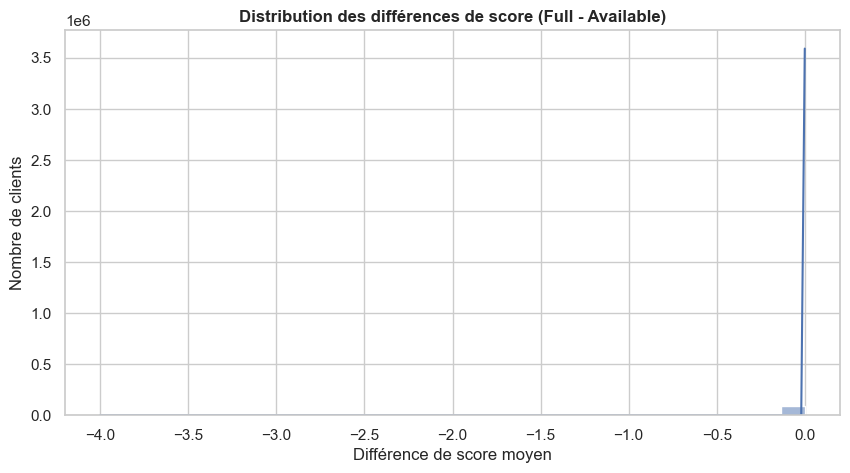

In [ ]:
# Calcul du délai entre livraison et avis
Base_finale_with_reviews = Base_finale[
    Base_finale['review_creation_date'].notna() &
    Base_finale['order_delivered_customer_date'].notna()
].copy()

Base_finale_with_reviews['delay_review_days'] = (
    Base_finale_with_reviews['review_creation_date'] - Base_finale_with_reviews['order_delivered_customer_date']
).dt.days

print("\n" + "="*60)
print("DISTRIBUTION DES DÉLAIS ENTRE LIVRAISON ET CRÉATION D'AVIS")
print("="*60)
display(Base_finale_with_reviews['delay_review_days'].describe())

print(f'\nNombre de clients uniques avec avis : {df_client["customer_unique_id"].nunique()}')

# Comparaison avg_review_score_available vs avg_review_score_full
print("\n" + "="*60)
print("ANALYSE DE L'IMPACT DE LA LATENCE SUR LES NOTES D'AVIS")
print("="*60)

# Filtrer pour les clients qui ont au moins un avis (complet ou disponible)
comparison_df = df_client[
    (df_client['has_available_review'] == 1) | (df_client['has_full_review'] == 1)
][['customer_unique_id', 'avg_review_score_available', 'avg_review_score_full']].copy()

comparison_df['score_diff'] = comparison_df['avg_review_score_full'] - comparison_df['avg_review_score_available']

# Clients dont le score disponible diffère du score complet
diff_clients_count = comparison_df[comparison_df['score_diff'] != 0].shape[0]
total_clients_with_reviews = comparison_df.shape[0]

print(f"Clients avec au moins une note d'avis (full ou available) : {total_clients_with_reviews}")
print(f"Clients dont la note d'avis moyenne diffère à cause de la latence : {diff_clients_count}")
if total_clients_with_reviews > 0:
    print(f"Pourcentage de clients impactés : {(diff_clients_count / total_clients_with_reviews * 100):.2f}%")

if diff_clients_count > 0:
    print("\nStatistiques sur la différence de score :")
    display(comparison_df['score_diff'].describe())

    plt.figure(figsize=(10, 5))
    sns.histplot(comparison_df['score_diff'], bins=30, kde=True)
    plt.title('Distribution des différences de score (Full - Available)', fontweight='bold')
    plt.xlabel('Différence de score moyen')
    plt.ylabel('Nombre de clients')
    plt.show()
else:
    print("\nAucune différence significative détectée, ou trop peu de clients avec reviews disponibles.")

In [ ]:
# P1-14 : Vérification NA après nettoyage et imputation
print("\n" + "="*60)
print("VÉRIFICATION DES VALEURS MANQUANTES APRÈS IMPUTATION")
print("="*60)

na_count = df_client.isna().sum()
na_total = na_count.sum()

print(f"\nTotal NA restants : {na_total}")

if na_count.sum() > 0:
    print("\nColonnes avec NA :")
    for col, count in na_count[na_count > 0].items():
        print(f"  {col:30} : {count:5} ({count/len(df_client)*100:5.2f}%)")
else:
    print(" Aucune valeur manquante - Nettoyage complet")

print(f"\nDimensions finales : {df_client.shape[0]} clients × {df_client.shape[1]} features")


VÉRIFICATION DES VALEURS MANQUANTES APRÈS IMPUTATION

Total NA restants : 0
 Aucune valeur manquante - Nettoyage complet

Dimensions finales : 93358 clients × 45 features


In [ ]:
# #9 : B7 - Vérification redondance avg_freight_value vs avg_freight_ratio
# Logique : si corrélation > 0.7, proposer retrait de avg_freight_ratio
print("\n" + "="*60)
print("#9 : B7 - ANALYSE REDONDANCE FRAIS DE PORT")
print("="*60)

corr_freight = df_client['avg_freight_value'].corr(df_client['avg_freight_ratio'])
print(f"\nCorrélation avg_freight_value ↔ avg_freight_ratio : {corr_freight:.3f}")

if abs(corr_freight) > 0.7:
    print("\n  REDONDANCE DÉTECTÉE : corrélation > 0.7")
    print("  → Recommandation : RETIRER avg_freight_ratio de NUM_COLS")
    print("  → Action : Dé-commenter la ligne ci-dessous pour nettoyer")
    # Décommenter pour activer :
    # NUM_COLS = [c for c in NUM_COLS if c != 'avg_freight_ratio']
    # print("   avg_freight_ratio retiré de NUM_COLS")
else:
    print("\n Pas de redondance : les deux variables sont complémentaires")
    print("   avg_freight_value : montant absolu")
    print("   avg_freight_ratio : proportion relative (utile pour segmentation)")


#9 : B7 - ANALYSE REDONDANCE FRAIS DE PORT

Corrélation avg_freight_value ↔ avg_freight_ratio : 0.090

 Pas de redondance : les deux variables sont complémentaires
   avg_freight_value : montant absolu
   avg_freight_ratio : proportion relative (utile pour segmentation)


Dans une approche de clustering robuste, l'inclusion simultanée des variables RFM (Récency, Frequency, Monetary) et de la CLV (Customer Lifetime Value) est proscrite pour éviter un biais de redondance informationnelle. La CLV étant une variable composite directement dérivée du produit de la fréquence et du montant, son intégration dans l'algorithme K-Means reviendrait à accorder un poids double aux mêmes dimensions transactionnelles. Pour préserver la stabilité et l'interprétabilité du modèle, nous avons fait le choix de conserver les variables RFM brutes pour l'entraînement, tout en réservant la CLV comme métrique d'évaluation post-hoc afin de valider la pertinence économique des segments obtenus.

## Autre features importants

In [ ]:
import numpy as np

# ── 6. VARIABLES COMPORTEMENTALES TEMPORELLES ───────────────────────────
# B4 : Créer UNIQUEMENT si Frequency >= 2 (sinon 1 achat = pas de "fréquent")
Base_finale['purchase_hour'] = Base_finale['order_purchase_timestamp'].dt.hour
Base_finale['purchase_day_of_week'] = Base_finale['order_purchase_timestamp'].dt.dayofweek # Lundi=0, Dimanche=6

# Pour les clients multi-achat : déterminer heure/jour les plus fréquents
multi_buy_data = Base_finale[Base_finale.groupby('customer_unique_id')['order_id'].transform('nunique') >= 2]

most_freq_hour = multi_buy_data.groupby('customer_unique_id')['purchase_hour'].agg(
    lambda x: x.mode()[0] if not x.mode().empty else np.nan
).rename('most_frequent_purchase_hour')

most_freq_day = multi_buy_data.groupby('customer_unique_id')['purchase_day_of_week'].agg(
    lambda x: x.mode()[0] if not x.mode().empty else np.nan
).rename('most_frequent_purchase_day')

# Ajouter au df_client
df_client = df_client.set_index('customer_unique_id').join([
    most_freq_hour, most_freq_day
]).reset_index()



# Pour les one-time buyers, imputer par mode global
df_client['most_frequent_purchase_hour'] = df_client['most_frequent_purchase_hour'].fillna(
    df_client['most_frequent_purchase_hour'].mode()[0] if len(df_client['most_frequent_purchase_hour'].mode()) > 0 else 12)
df_client['most_frequent_purchase_day'] = df_client['most_frequent_purchase_day'].fillna(
    df_client['most_frequent_purchase_day'].mode()[0] if len(df_client['most_frequent_purchase_day'].mode()) > 0 else 2)

# FIX: Remove duplicated spend_ columns (ending with '_y')
spend_y_cols = [col for col in df_client.columns if col.startswith("spend_('price',") and col.endswith("_y")]
if spend_y_cols:
    print(f"Dropping duplicate spend_ columns: {spend_y_cols}")
    df_client = df_client.drop(columns=spend_y_cols)

print(f'\n df_client shape    : {df_client.shape}')
print(f' NA restants       : {df_client.isna().sum().sum()}')
print(f' Features créées   : {len(df_client.columns)} colonnes')
display(df_client.head(3))


 df_client shape    : (93358, 47)
 NA restants       : 0
 Features créées   : 47 colonnes


,customer_unique_id,Recency,Frequency,Monetary,avg_delivery_days,late_delivery_rate,avg_delivery_delta,preferred_payment,avg_installments,product_diversity,avg_order_value,avg_freight_value,preferred_category,avg_lat,avg_lng,avg_freight_ratio,std_freight_ratio,review_participation_rate,cancellation_rate,avg_review_score_full,has_full_review,avg_review_score_available,has_available_review,has_delivered_orders,has_cancelled_orders,avg_basket_size,first_purchase_category,first_purchase_value,inter_purchase_time,dissatisfaction_rate_proxy,avg_seller_rating,payment_type_diversity,"spend_('price', 'electronics')","spend_('price', 'health_beauty')","spend_('price', 'home')","spend_('price', 'other')","spend_('price', 'sports_leisure')",dist_sao_paulo,recency_ratio,CLV_estimate,is_repeat_customer,has_delivery,never_delivered,has_review,has_delivery_info,most_frequent_purchase_hour,most_frequent_purchase_day
0,0000366f3b9a7992bf8c76cfdf3221e2,161.00,1.00,141.90,6.00,0.00,4.00,credit_card,8.00,1.00,129.90,12.00,home,-23.34,-46.83,0.08,0.00,1.00,0.00,5.00,1.00,5.00,1.00,1.00,0.00,1.00,home,141.90,42.00,0.00,4.18,1.00,0.00,0.00,129.90,0.00,0.00,31.06,0.21,67.14,0.00,1.00,0.00,1.00,1.00,10.00,0.00
1,0000b849f77a49e4a4ce2b2a4ca5be3f,164.00,1.00,27.19,3.00,0.00,4.00,credit_card,1.00,1.00,18.90,8.29,health_beauty,-23.56,-46.79,0.30,0.00,1.00,0.00,4.00,1.00,4.00,1.00,1.00,0.00,1.00,health_beauty,27.19,42.00,0.00,4.08,1.00,0.00,18.90,0.00,0.00,0.00,16.19,0.21,12.86,0.00,1.00,0.00,1.00,1.00,10.00,0.00
2,0000f46a3911fa3c0805444483337064,586.00,1.00,86.22,25.00,0.00,1.00,credit_card,8.00,1.00,69.00,17.22,office,-27.54,-48.63,0.20,0.00,1.00,0.00,3.00,1.00,3.00,1.00,1.00,0.00,1.00,office,86.22,42.00,0.00,4.19,1.00,0.00,0.00,0.00,69.00,0.00,487.41,0.76,40.79,0.00,1.00,0.00,1.00,1.00,10.00,0.00


In [ ]:
#

## Traitement des outliers

In [ ]:
import warnings
warnings.filterwarnings('ignore')

# --- FEATURE LISTS FOR CLUSTERING MODELS (Full vs. Cold Start) ---

# Ensure df_client exists to correctly identify 'spend_' columns
# This assumes df_client is correctly built in a preceding cell (e.g., 47917bf6)
# If df_client is not yet available, this part might need adjustment or a dummy df_client.
if 'df_client' not in locals():
    print("Warning: df_client not found. Please ensure feature engineering cells have been run.")
    # Fallback for defining spend_cols if df_client not yet in scope (for initial execution)
    spend_cols = ["spend_electronics", "spend_health_beauty", "spend_home", "spend_other", "spend_sports_leisure"]
else:
    spend_cols = [c for c in df_client.columns if c.startswith('spend_') and not c.endswith(('_x', '_y'))]

# 1. Numerical Features for the FULL Model (available after delivery/review)
FEATURES_FULL_NUM = [
    'Recency', 'Frequency', # RFM base
    'Monetary', # Will be log-transformed
    'avg_delivery_days', 'late_delivery_rate', # Delivery metrics
    'avg_review_score_available', 'review_participation_rate', # Review metrics
    'avg_installments', 'payment_type_diversity', # Payment metrics
    'avg_order_value', 'avg_freight_value', 'avg_freight_ratio', 'std_freight_ratio', # Product/Freight metrics (avg_order_value replaces avg_item_price)
    'dist_sao_paulo', # Geographic metric
    'cancellation_rate', # Ratios/Rates
    'avg_basket_size', 'first_purchase_value', 'inter_purchase_time', # New behavioral metrics
    'dissatisfaction_rate_proxy', # Renamed from return_rate_proxy # New reputation metrics
    'never_delivered', 'has_full_review', 'has_delivery_info', # Status/Flag metrics
    'has_cancelled_orders' # Status/Flag metrics
] + spend_cols

# Define NUM_COLS for general use (e.g., correlation matrix)
NUM_COLS = FEATURES_FULL_NUM # This will be used as the base for numerical features before log-transformation

# 2. Categorical Features for the FULL Model (for K-Prototypes)
FEATURES_FULL_CAT = [
    'preferred_payment', 'preferred_category', 'first_purchase_category'
]

# 3. Numerical Features for the COLD START Model (T+0 features)
FEATURES_COLD_START_NUM = [
    'Recency', 'Frequency', # RFM base
    'Monetary', # Will be log-transformed
    'avg_installments', 'payment_type_diversity', # Payment metrics
    'avg_order_value', 'avg_freight_value', 'avg_freight_ratio', 'std_freight_ratio', # Product/Freight metrics (avg_order_value replaces avg_item_price)
    'dist_sao_paulo', # Geographic metric
    'cancellation_rate', # Ratios/Rates (assuming historical rate can be known at T+0)
    'avg_basket_size', 'first_purchase_value', 'inter_purchase_time', # New behavioral metrics
    'has_cancelled_orders' # Status/Flag metrics
] + spend_cols

# 4. Categorical Features for the COLD START Model (for K-Prototypes at T+0)
FEATURES_COLD_START_CAT = [
    'preferred_payment', 'preferred_category', 'first_purchase_category'
]

# Features to apply Winsorization (long-tailed distributions)
# Note: This applies to original (non-log) values before transformation for scaling.
COLS_TO_WINSORIZE_NUMERICAL = [
    'Monetary', 'avg_order_value', 'avg_freight_value', 'first_purchase_value' # avg_order_value replaces avg_item_price
]



--- Applying Winsorization ---
  Monetary                  : max    13664 ->     1468 | mean  165.2 ->  161.8
  avg_order_value           : max    13440 ->     1350 | mean  137.5 ->  134.1
  avg_freight_value         : max      410 ->      107 | mean   20.2 ->   20.0
  first_purchase_value      : max    13664 ->     1427 | mean  160.3 ->  156.9
--- Winsorization Applied ---
Applying log1p transformation to 'Monetary'.
Applying log1p transformation to 'spend_('price', 'electronics')'.
Applying log1p transformation to 'spend_('price', 'health_beauty')'.
Applying log1p transformation to 'spend_('price', 'home')'.
Applying log1p transformation to 'spend_('price', 'other')'.
Applying log1p transformation to 'spend_('price', 'sports_leisure')'.
NUM_COLS_LOG prepared with 35 features for scaling.
First 5 columns: ['Recency', 'Frequency', 'Monetary_log', 'avg_delivery_days', 'late_delivery_rate']


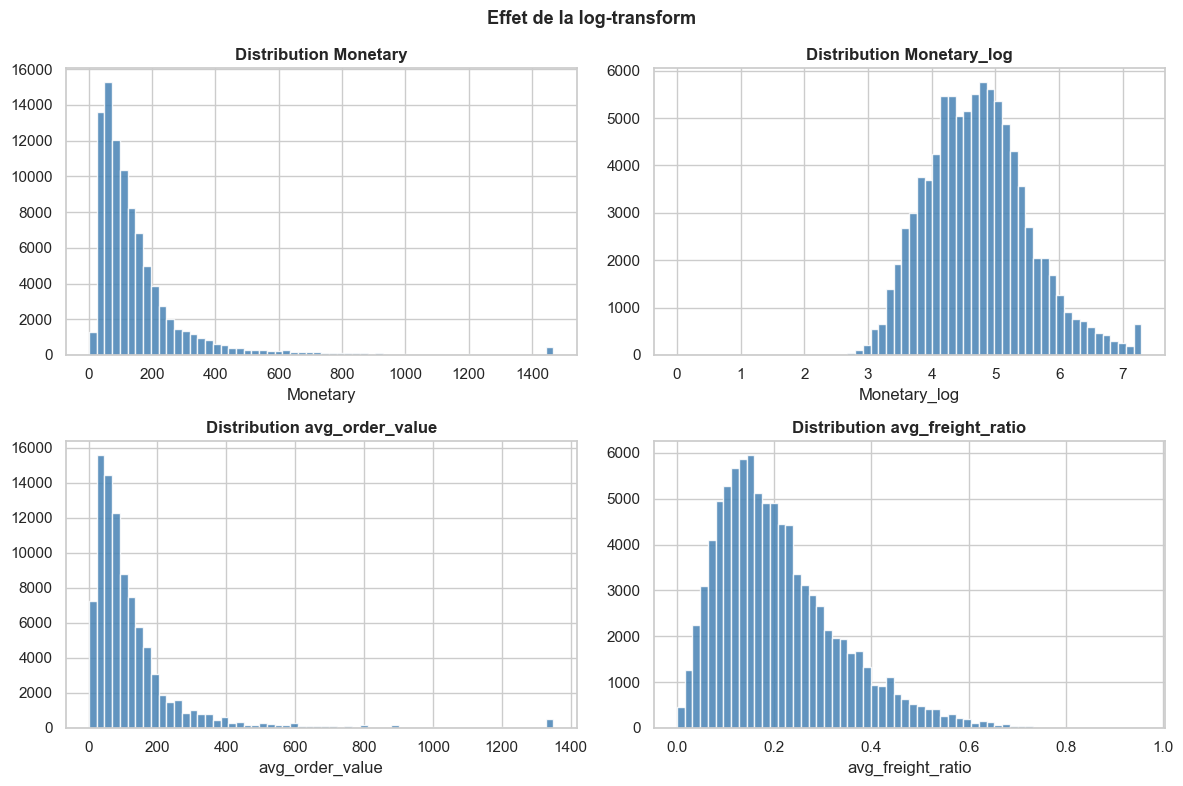

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


current_spend_cols = [c for c in df_client.columns if c.startswith("spend_('price',") and c.endswith("_x")]
# If no _x suffix, assume the original names are the correct ones after dropping _y
if not current_spend_cols:
    current_spend_cols = [c for c in df_client.columns if c.startswith("spend_('price',") and not c.endswith("_y")]

# 1. Update FEATURES_FULL_NUM to include all desired numerical features
# This ensures that X_winsorized is built with the complete set of features.
FEATURES_FULL_NUM = [
    'Recency', 'Frequency', # RFM base
    'Monetary', # Will be log-transformed
    'avg_delivery_days', 'late_delivery_rate', # Delivery metrics
    'avg_review_score_available', 'review_participation_rate', # Review metrics
    'avg_installments', 'payment_type_diversity', # Payment metrics
    'product_diversity', # Add missing feature: Product diversity
    'avg_order_value', 'avg_freight_value', 'avg_freight_ratio', 'std_freight_ratio', # Product/Freight metrics
    'avg_lat', 'avg_lng', # Add missing geographical features
    'dist_sao_paulo', # Geographic metric
    'recency_ratio', # ADDED: explicit inclusion of recency_ratio
    'cancellation_rate', # Ratios/Rates
    'avg_basket_size', 'first_purchase_value', 'inter_purchase_time', # New behavioral metrics
    'dissatisfaction_rate_proxy', # CORRECTED name from 'return_rate_proxy'
    'avg_seller_rating', # Add missing feature: Average seller rating
    'is_repeat_customer', # Flag
    'never_delivered', # Status/Flag metrics (preferred over has_delivery / has_delivery_info)
    'has_full_review', # Status/Flag metrics (preferred over has_available_review / has_review)
    'has_cancelled_orders', # Status/Flag metrics
    'most_frequent_purchase_hour', 'most_frequent_purchase_day' # Add missing behavioral features
] + current_spend_cols # Add the corrected list of spend columns

# Ensure all columns in FEATURES_FULL_NUM actually exist in df_client.columns
FEATURES_FULL_NUM = [col for col in FEATURES_FULL_NUM if col in df_client.columns]


# 2. Create X_winsorized with the complete set of numerical features
# This step is crucial to avoid the KeyError during scaling.
X_num = df_client[FEATURES_FULL_NUM].copy()
X_winsorized = X_num.copy()


# 3. Apply Winsorization (moved from ekw1AcfUcDs8)
print("\n--- Applying Winsorization ---")
for col in COLS_TO_WINSORIZE_NUMERICAL:
    if col in X_winsorized.columns:
        before_max  = X_winsorized[col].max()
        before_mean = X_winsorized[col].mean()
        non_nan_values = X_winsorized[col].dropna()
        if not non_nan_values.empty:
            X_winsorized.loc[X_winsorized[col].notna(), col] = mstats.winsorize(non_nan_values, limits=[0, 0.005])
            after_max   = X_winsorized[col].max()
            after_mean  = X_winsorized[col].mean()
            print(f"  {col:25} : max {before_max:8.0f} -> {after_max:8.0f} | mean {before_mean:6.1f} -> {after_mean:6.1f}")
        else:
            print(f"  Warning: Column '{col}' contains only NaN values or is empty after dropping NaNs. Skipping winsorization.")
    else:
        print(f"  Warning: Column '{col}' not found in X_winsorized. Skipping winsorization for this column.")
print("--- Winsorization Applied ---")


# 4. Apply log-transformations for Monetary and spend_cols
# Check for Monetary_log and apply if not already present
if 'Monetary_log' not in X_winsorized.columns:
    print("Applying log1p transformation to 'Monetary'.")
    X_winsorized['Monetary_log'] = np.log1p(X_winsorized['Monetary'])

new_spend_log_cols = []
for col in current_spend_cols:
    log_col = f'{col}_log'
    if col in X_winsorized.columns and log_col not in X_winsorized.columns:
        print(f"Applying log1p transformation to '{col}'.")
        X_winsorized[log_col] = np.log1p(X_winsorized[col])
    new_spend_log_cols.append(log_col)


# 5. Build NUM_COLS_LOG from the refined FEATURES_FULL_NUM, applying log transforms where needed
NUM_COLS_LOG = []
for col in FEATURES_FULL_NUM:
    if col == 'Monetary':
        if 'Monetary_log' in X_winsorized.columns:
            NUM_COLS_LOG.append('Monetary_log')
        else:
            NUM_COLS_LOG.append(col) # Fallback if log not created
    elif col in current_spend_cols:
        log_col_name = f'{col}_log'
        if log_col_name in X_winsorized.columns:
            NUM_COLS_LOG.append(log_col_name)
        else:
            print(f"WARNING: Expected log-transformed column '{log_col_name}' not found. Using original '{col}'.")
            NUM_COLS_LOG.append(col)
    # Explicitly exclude redundant/less-preferred flags for NUM_COLS_LOG
    # These were previously handled in the `elif col not in [...]` part, now explicitly handled by not adding them.
    elif col in ['avg_delivery_delta', 'avg_review_score_full', 'has_available_review', 'has_delivered_orders', 'has_review', 'has_delivery_info']:
        pass # These are explicitly chosen to be excluded for clustering or replaced by better alternatives
    else:
        NUM_COLS_LOG.append(col)

print(f"NUM_COLS_LOG prepared with {len(NUM_COLS_LOG)} features for scaling.")
print(f"First 5 columns: {NUM_COLS_LOG[:5]}")

# Visualisation avant / après log-transform
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

for i, col in enumerate(['Monetary', 'Monetary_log', 'avg_order_value', 'avg_freight_ratio']):
    ax = axes[i // 2][i % 2]
    if col in X_winsorized.columns:
        X_winsorized[col].hist(bins=60, ax=ax, color='steelblue', edgecolor='white', alpha=0.85)
        ax.set_title(f'Distribution {col}', fontweight='bold')
        ax.set_xlabel(col)

plt.suptitle('Effet de la log-transform', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


ANALYSE DE NORMALITÉ : MONETARY AVANT ET APRÈS LOG-TRANSFORMATION


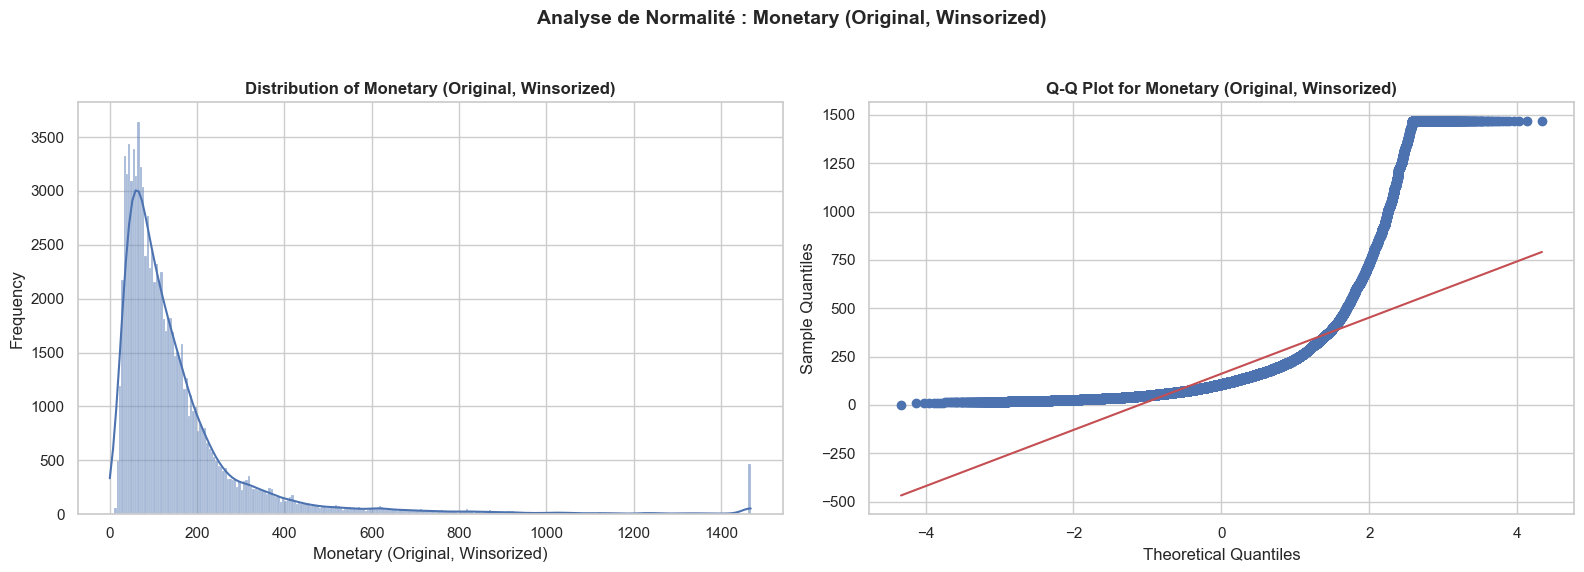


D'Agostino's K-squared test for Monetary (Original, Winsorized):
  Statistic = 75096.87, p-value = 0.000e+00
  Conclusion: La variable Monetary (Winsorized) n'est PAS normalement distribuée (p < 0.05)


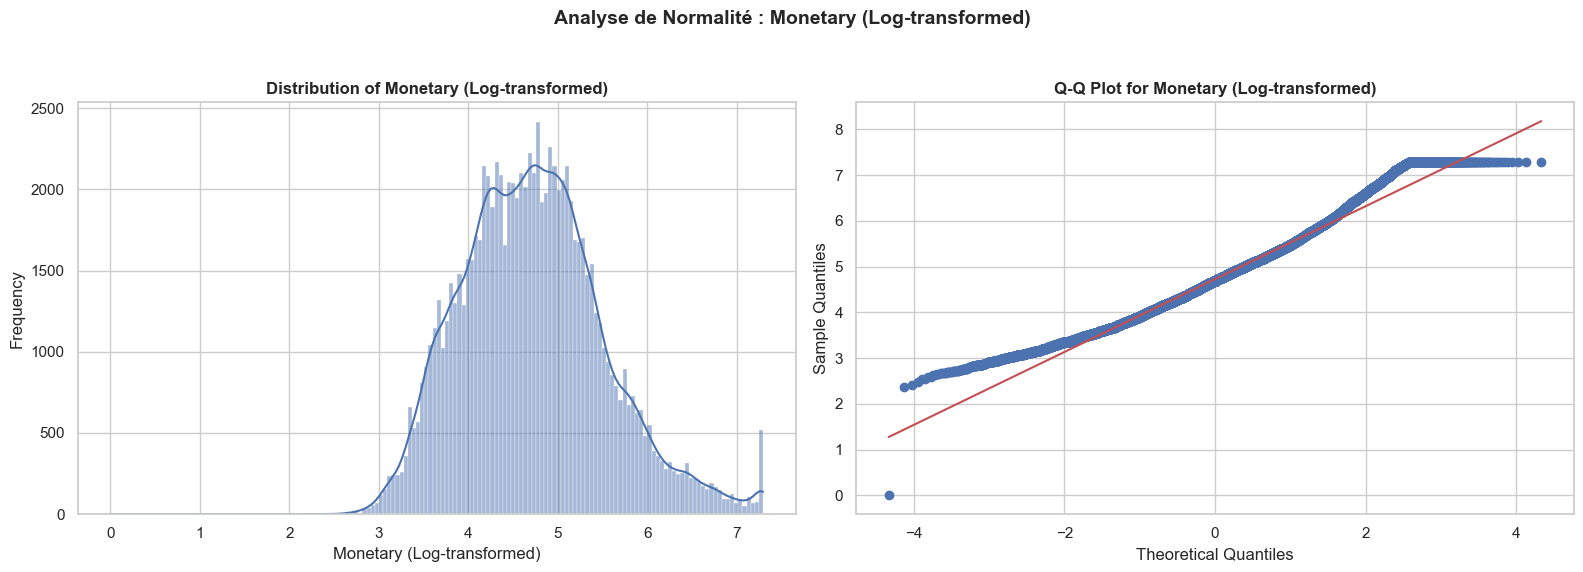


D'Agostino's K-squared test for Monetary (Log-transformed):
  Statistic = 3288.11, p-value = 0.000e+00
  Conclusion: La variable Monetary (Log-transformed) n'est PAS normalement distribuée (p < 0.05)

RÉSUMÉ DES TESTS DE NORMALITÉ
La log-transformation réduit significativement l'asymétrie et l'aplatissement de la distribution.
Cependant, pour de grands ensembles de données (comme le nôtre), les tests statistiques formels comme celui de D'Agostino
rejettent souvent l'hypothèse de normalité même pour des déviations minimes. Les Q-Q plots visuels sont donc
essentiels pour une évaluation qualitative et montrent une bien meilleure approximation à une distribution normale
après transformation.



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import numpy as np # Import numpy if not already imported

def plot_and_test_normality(data, title, ax1, ax2):
    """
    Plots histogram and Q-Q plot, and performs D'Agostino's K-squared test for normality.
    """
    sns.histplot(data.dropna(), kde=True, ax=ax1)
    ax1.set_title(f'Distribution of {title}', fontsize=12, fontweight='bold')
    ax1.set_xlabel(title)
    ax1.set_ylabel('Frequency')

    stats.probplot(data.dropna(), dist="norm", plot=ax2)
    ax2.set_title(f'Q-Q Plot for {title}', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Theoretical Quantiles')
    ax2.set_ylabel('Sample Quantiles')

    # D'Agostino's K-squared test
    # If p-value < alpha, reject null hypothesis (not normal)
    k2, p_value = stats.normaltest(data.dropna())
    return k2, p_value

print("\n" + "="*60)
print("ANALYSE DE NORMALITÉ : MONETARY AVANT ET APRÈS LOG-TRANSFORMATION")
print("="*60)

# --- Before log1p transformation (using X_winsorized['Monetary']) ---
monetary_original = X_winsorized['Monetary']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
k2_orig, p_orig = plot_and_test_normality(monetary_original, 'Monetary (Original, Winsorized)', axes[0], axes[1])
plt.suptitle('Analyse de Normalité : Monetary (Original, Winsorized)', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print(f"\nD'Agostino's K-squared test for Monetary (Original, Winsorized):")
print(f"  Statistic = {k2_orig:.2f}, p-value = {p_orig:.3e}")
if p_orig < 0.05:
    print("  Conclusion: La variable Monetary (Winsorized) n'est PAS normalement distribuée (p < 0.05)")
else:
    print("  Conclusion: La variable Monetary (Winsorized) semble normalement distribuée (p >= 0.05)")

# --- Perform log1p transformation here before using Monetary_log ---
X_winsorized['Monetary_log'] = np.log1p(X_winsorized['Monetary'])

# --- After log1p transformation (using X_winsorized['Monetary_log']) ---
monetary_log_transformed = X_winsorized['Monetary_log']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
k2_log, p_log = plot_and_test_normality(monetary_log_transformed, 'Monetary (Log-transformed)', axes[0], axes[1])
plt.suptitle('Analyse de Normalité : Monetary (Log-transformed)', fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print(f"\nD'Agostino's K-squared test for Monetary (Log-transformed):")
print(f"  Statistic = {k2_log:.2f}, p-value = {p_log:.3e}")
if p_log < 0.05:
    print("  Conclusion: La variable Monetary (Log-transformed) n'est PAS normalement distribuée (p < 0.05)")
else:
    print("  Conclusion: La variable Monetary (Log-transformed) semble normalement distribuée (p >= 0.05)")

print("\n" + "="*60)
print("RÉSUMÉ DES TESTS DE NORMALITÉ")
print("""La log-transformation réduit significativement l'asymétrie et l'aplatissement de la distribution.
Cependant, pour de grands ensembles de données (comme le nôtre), les tests statistiques formels comme celui de D'Agostino
rejettent souvent l'hypothèse de normalité même pour des déviations minimes. Les Q-Q plots visuels sont donc
essentiels pour une évaluation qualitative et montrent une bien meilleure approximation à une distribution normale
après transformation.
""")
print("="*60)

In [ ]:
# Scaling : #11 AJOUTER spend_* au scaling
scaler = StandardScaler()

# NUM_COLS_LOG should already be defined from previous cell
if 'NUM_COLS_LOG' not in locals():
    raise ValueError("NUM_COLS_LOG not defined. Please run the previous feature engineering cells.")

print(f"✓ #11 : Scaling appliqué à {len(NUM_COLS_LOG)} features")
print(f"    (incluant {len([c for c in NUM_COLS_LOG if c.startswith('spend_')])} colonnes spend_*) ")

X_scaled = scaler.fit_transform(X_winsorized[NUM_COLS_LOG])
X_scaled_df = pd.DataFrame(X_scaled, columns=NUM_COLS_LOG, index=df_client.index)

# Vérification
print(f'\nX_scaled shape : {X_scaled.shape}')
print(f'Moyenne post-scaling (doit être ~0) :')
print(X_scaled_df.mean().round(4))
print(f'\nÉcart-type post-scaling (doit être ~1) :')
print(X_scaled_df.std().round(4))

✓ #11 : Scaling appliqué à 35 features
    (incluant 5 colonnes spend_*) 

X_scaled shape : (93358, 35)
Moyenne post-scaling (doit être ~0) :
Recency                                 -0.00
Frequency                               -0.00
Monetary_log                             0.00
avg_delivery_days                       -0.00
late_delivery_rate                      -0.00
avg_review_score_available               0.00
review_participation_rate                0.00
avg_installments                         0.00
payment_type_diversity                  -0.00
product_diversity                       -0.00
avg_order_value                         -0.00
avg_freight_value                       -0.00
avg_freight_ratio                        0.00
std_freight_ratio                       -0.00
avg_lat                                  0.00
avg_lng                                 -0.00
dist_sao_paulo                          -0.00
recency_ratio                            0.00
cancellation_rate             

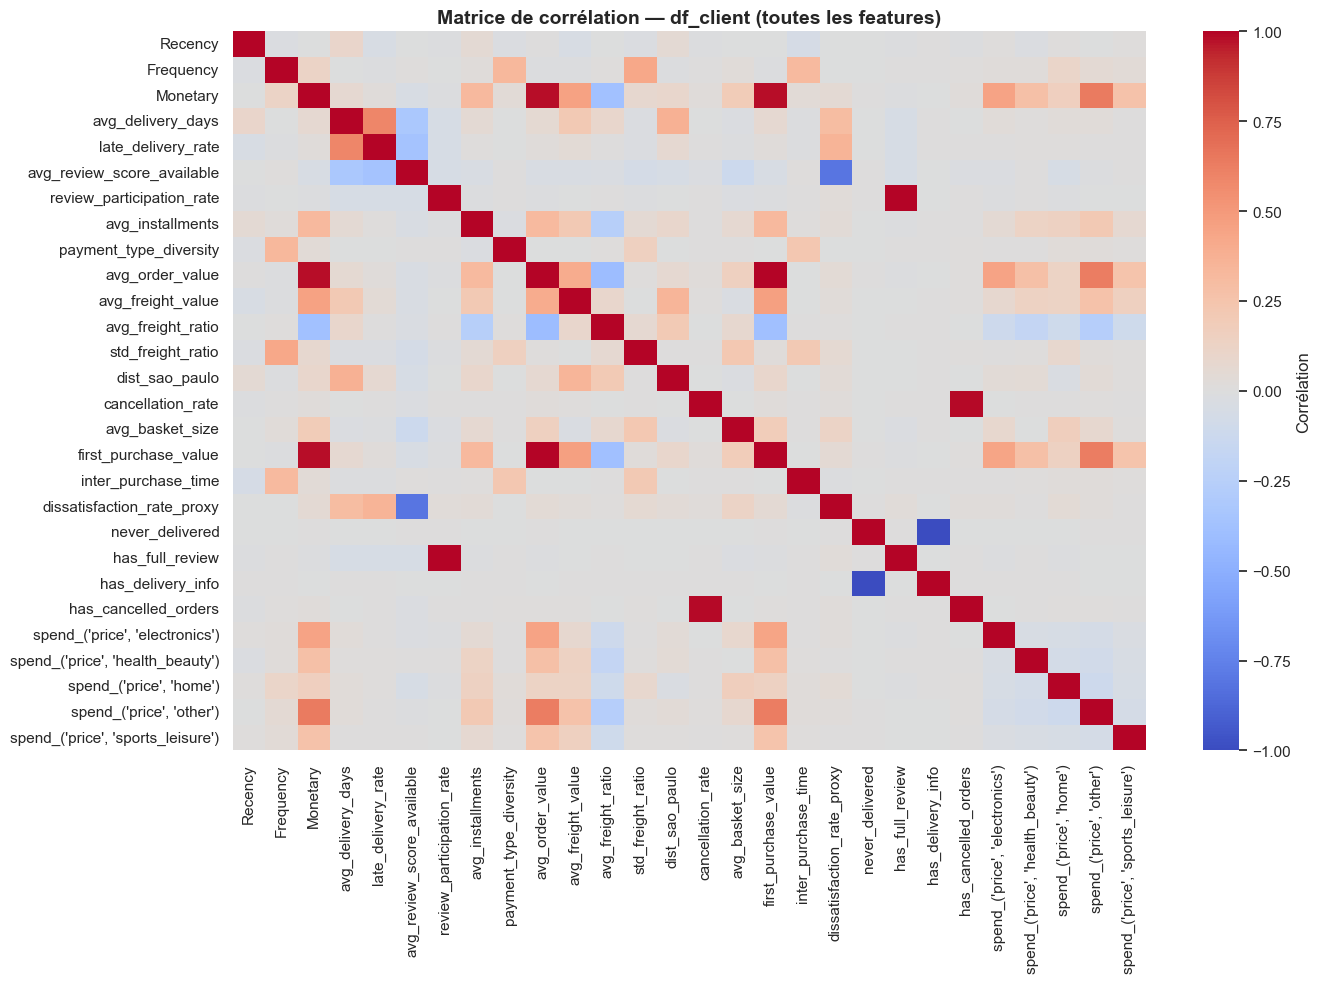


Correlations fortes (> 0.7):
  Monetary ↔ avg_order_value : 0.978
  Monetary ↔ first_purchase_value : 0.982
  avg_review_score_available ↔ dissatisfaction_rate_proxy : -0.808
  review_participation_rate ↔ has_full_review : 0.994
  avg_order_value ↔ first_purchase_value : 0.993
  cancellation_rate ↔ has_cancelled_orders : 0.990
  never_delivered ↔ has_delivery_info : -1.000


In [ ]:
# P1-12 : Heatmap de corrélation sur df_client
corr_matrix = df_client[NUM_COLS].corr()
plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0, fmt='.2f', cbar_kws={'label': 'Corrélation'})
plt.title('Matrice de corrélation — df_client (toutes les features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nCorrelations fortes (> 0.7):")
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            print(f"  {corr_matrix.columns[i]} ↔ {corr_matrix.columns[j]} : {corr_matrix.iloc[i, j]:.3f}")

In [ ]:
# P1-13 : Vérification skewness post-log-transform et scaling
from scipy.stats import skew

print("\n" + "="*80)
print("VÉRIFICATION SKEWNESS POST-TRANSFORMATION")
print("="*80)

print("\nSkewness avant log-transform (X_winsorized original):")
for col in ['Monetary', 'avg_item_price', 'avg_freight_value']:
    if col in X_winsorized.columns:
        s = skew(X_winsorized[col].dropna())
        print(f"  {col:25} : {s:7.3f} {'(très asymétrique)' if abs(s) > 1 else '(modéré)' if abs(s) > 0.5 else '(symétrique)'}")

print("\nSkewness après log-transform :")
# #10 : CLV_log RETIRÉE (code mort — CLV proscrite du clustering)
for col in ['Monetary_log']:
    if col in X_winsorized.columns:
        s = skew(X_winsorized[col].dropna())
        print(f"  {col:25} : {s:7.3f} {'(très asymétrique)' if abs(s) > 1 else '(modéré)' if abs(s) > 0.5 else '(symétrique)'}")

print("\nSkewness après scaling (X_scaled_df):")
for col in NUM_COLS_LOG[:5]:  # Afficher les 5 premières
    if col in X_scaled_df.columns:
        s = skew(X_scaled_df[col].dropna())
        print(f"  {col:25} : {s:7.3f}")
print("  ...")

print("\n✓ Les distributions doivent être réduites après scaling (moyenne ≈ 0, écart-type ≈ 1)")


VÉRIFICATION SKEWNESS POST-TRANSFORMATION

Skewness avant log-transform (X_winsorized original):
  Monetary                  :   3.856 (très asymétrique)
  avg_freight_value         :   3.231 (très asymétrique)

Skewness après log-transform :
  Monetary_log              :   0.468 (symétrique)

Skewness après scaling (X_scaled_df):
  Recency                   :   0.447
  Frequency                 :  11.095
  Monetary_log              :   0.468
  avg_delivery_days         :   3.884
  late_delivery_rate        :   3.061
  ...

✓ Les distributions doivent être réduites après scaling (moyenne ≈ 0, écart-type ≈ 1)


## Analyse additionnelle : Tendances clients

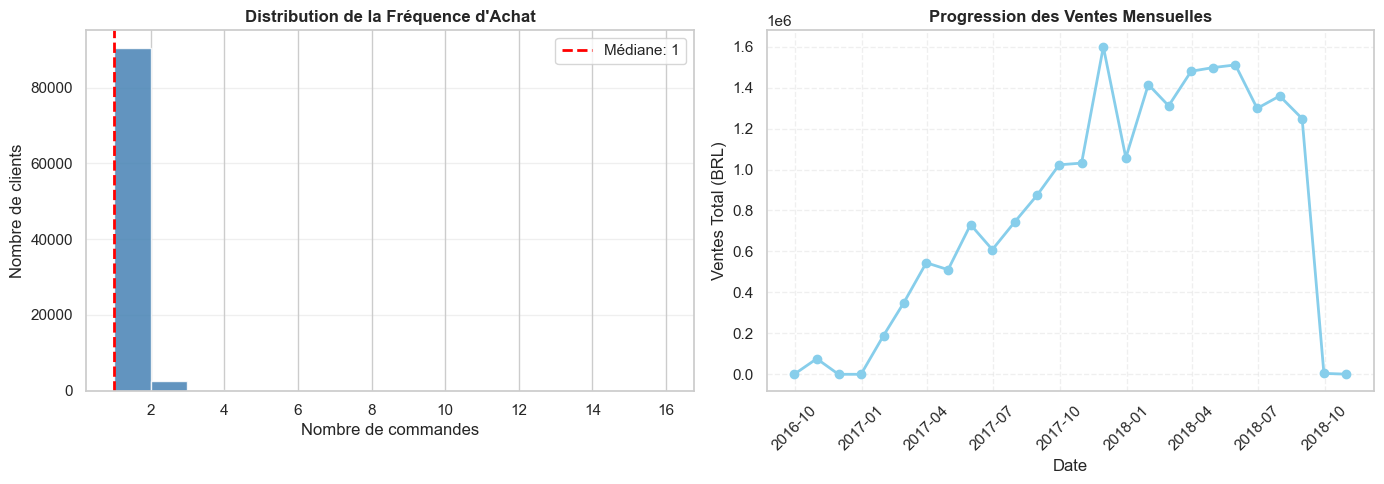

97.0% des clients sont des "one-time buyers"
Fréquence moyenne : 1.03 commandes par client


In [ ]:
# Analyse de la fréquence d'achat
pct_one_purchase = (df_client['Frequency'] == 1).sum() / len(df_client) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogramme fréquence
axes[0].hist(df_client['Frequency'], bins=range(1, int(df_client['Frequency'].max()) + 2),
             color='steelblue', edgecolor='white', alpha=0.85)
axes[0].axvline(df_client['Frequency'].median(), color='red', linestyle='--', linewidth=2,
                label=f'Médiane: {df_client["Frequency"].median():.0f}')
axes[0].set_title('Distribution de la Fréquence d\'Achat', fontweight='bold', fontsize=12)
axes[0].set_xlabel('Nombre de commandes')
axes[0].set_ylabel('Nombre de clients')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Timeline des ventes
Base_finale_sorted = Base_finale.set_index('order_purchase_timestamp').sort_index()
monthly_sales = Base_finale_sorted['payment_value'].resample('M').sum()
axes[1].plot(monthly_sales.index, monthly_sales.values, marker='o', linestyle='-', color='skyblue', linewidth=2)
axes[1].set_title('Progression des Ventes Mensuelles', fontweight='bold', fontsize=12)
axes[1].set_xlabel('Date')
axes[1].set_ylabel('Ventes Total (BRL)')
axes[1].grid(True, linestyle='--', alpha=0.3)
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print(f'{pct_one_purchase:.1f}% des clients sont des "one-time buyers"')
print(f'Fréquence moyenne : {df_client["Frequency"].mean():.2f} commandes par client')

In [ ]:
# nombre de ligne dans la base
df_client.shape[0]

93358

In [ ]:
print(df_client.columns.tolist())

['customer_unique_id', 'Recency', 'Frequency', 'Monetary', 'avg_delivery_days', 'late_delivery_rate', 'avg_delivery_delta', 'preferred_payment', 'avg_installments', 'product_diversity', 'avg_order_value', 'avg_freight_value', 'preferred_category', 'avg_lat', 'avg_lng', 'avg_freight_ratio', 'std_freight_ratio', 'review_participation_rate', 'cancellation_rate', 'avg_review_score_full', 'has_full_review', 'avg_review_score_available', 'has_available_review', 'has_delivered_orders', 'has_cancelled_orders', 'avg_basket_size', 'first_purchase_category', 'first_purchase_value', 'inter_purchase_time', 'dissatisfaction_rate_proxy', 'avg_seller_rating', 'payment_type_diversity', "spend_('price', 'electronics')", "spend_('price', 'health_beauty')", "spend_('price', 'home')", "spend_('price', 'other')", "spend_('price', 'sports_leisure')", 'dist_sao_paulo', 'recency_ratio', 'CLV_estimate', 'is_repeat_customer', 'has_delivery', 'never_delivered', 'has_review', 'has_delivery_info', 'most_frequent_pu

In [ ]:
df_client.to_csv('../data/Base.csv', index=False)

Analyse Exploratoire des données transformées


ANALYSE EXPLORATOIRE DE df_client (DONNÉES TRANSFORMÉES)

--- 1. Informations Générales ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93358 entries, 0 to 93357
Data columns (total 47 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   customer_unique_id                 93358 non-null  object 
 1   Recency                            93358 non-null  float64
 2   Frequency                          93358 non-null  float64
 3   Monetary                           93358 non-null  float64
 4   avg_delivery_days                  93358 non-null  float64
 5   late_delivery_rate                 93358 non-null  float64
 6   avg_delivery_delta                 93358 non-null  float64
 7   preferred_payment                  93358 non-null  object 
 8   avg_installments                   93358 non-null  float64
 9   product_diversity                  93358 non-null  float64
 10  avg_order_value          

,customer_unique_id,Recency,Frequency,Monetary,avg_delivery_days,late_delivery_rate,avg_delivery_delta,preferred_payment,avg_installments,product_diversity,avg_order_value,avg_freight_value,preferred_category,avg_lat,avg_lng,avg_freight_ratio,std_freight_ratio,review_participation_rate,cancellation_rate,avg_review_score_full,has_full_review,avg_review_score_available,has_available_review,has_delivered_orders,has_cancelled_orders,avg_basket_size,first_purchase_category,first_purchase_value,inter_purchase_time,dissatisfaction_rate_proxy,avg_seller_rating,payment_type_diversity,"spend_('price', 'electronics')","spend_('price', 'health_beauty')","spend_('price', 'home')","spend_('price', 'other')","spend_('price', 'sports_leisure')",dist_sao_paulo,recency_ratio,CLV_estimate,is_repeat_customer,has_delivery,never_delivered,has_review,has_delivery_info,most_frequent_purchase_hour,most_frequent_purchase_day
0,0000366f3b9a7992bf8c76cfdf3221e2,161.00,1.00,141.90,6.00,0.00,4.00,credit_card,8.00,1.00,129.90,12.00,home,-23.34,-46.83,0.08,0.00,1.00,0.00,5.00,1.00,5.00,1.00,1.00,0.00,1.00,home,141.90,42.00,0.00,4.18,1.00,0.00,0.00,129.90,0.00,0.00,31.06,0.21,67.14,0.00,1.00,0.00,1.00,1.00,10.00,0.00
1,0000b849f77a49e4a4ce2b2a4ca5be3f,164.00,1.00,27.19,3.00,0.00,4.00,credit_card,1.00,1.00,18.90,8.29,health_beauty,-23.56,-46.79,0.30,0.00,1.00,0.00,4.00,1.00,4.00,1.00,1.00,0.00,1.00,health_beauty,27.19,42.00,0.00,4.08,1.00,0.00,18.90,0.00,0.00,0.00,16.19,0.21,12.86,0.00,1.00,0.00,1.00,1.00,10.00,0.00
2,0000f46a3911fa3c0805444483337064,586.00,1.00,86.22,25.00,0.00,1.00,credit_card,8.00,1.00,69.00,17.22,office,-27.54,-48.63,0.20,0.00,1.00,0.00,3.00,1.00,3.00,1.00,1.00,0.00,1.00,office,86.22,42.00,0.00,4.19,1.00,0.00,0.00,0.00,69.00,0.00,487.41,0.76,40.79,0.00,1.00,0.00,1.00,1.00,10.00,0.00



--- 2. Statistiques Descriptives (Numériques) ---


,count,mean,std,min,25%,50%,75%,max
Recency,93358.00,287.11,152.59,50.00,164.00,268.00,395.00,763.00
Frequency,93358.00,1.03,0.21,1.00,1.00,1.00,1.00,15.00
Monetary,93358.00,165.20,226.31,0.00,63.05,107.78,182.56,13664.08
avg_delivery_days,93358.00,12.10,9.55,0.00,6.00,10.00,15.00,209.00
late_delivery_rate,93358.00,0.08,0.27,0.00,0.00,0.00,0.00,1.00
avg_delivery_delta,93358.00,10.85,10.14,-189.00,6.00,11.00,16.00,146.00
avg_installments,93358.00,2.92,2.69,0.00,1.00,2.00,4.00,24.00
product_diversity,93358.00,1.02,0.15,1.00,1.00,1.00,1.00,4.00
avg_order_value,93358.00,137.51,209.86,0.85,46.00,86.99,149.90,13440.00
avg_freight_value,93358.00,20.18,15.71,0.00,13.37,16.39,21.19,409.68



--- 2. Statistiques Descriptives (Catégorielles) ---


,count,unique,top,freq
customer_unique_id,93358,93358,0000366f3b9a7992bf8c76cfdf3221e2,1
preferred_payment,93358,5,credit_card,71513
preferred_category,93358,10,home,15849
first_purchase_category,93358,10,home,15892



--- 3. Vérification Finale des Valeurs Manquantes ---
Aucune valeur manquante détectée dans df_client.

--- 4. Distributions des Variables Numériques Clés ---


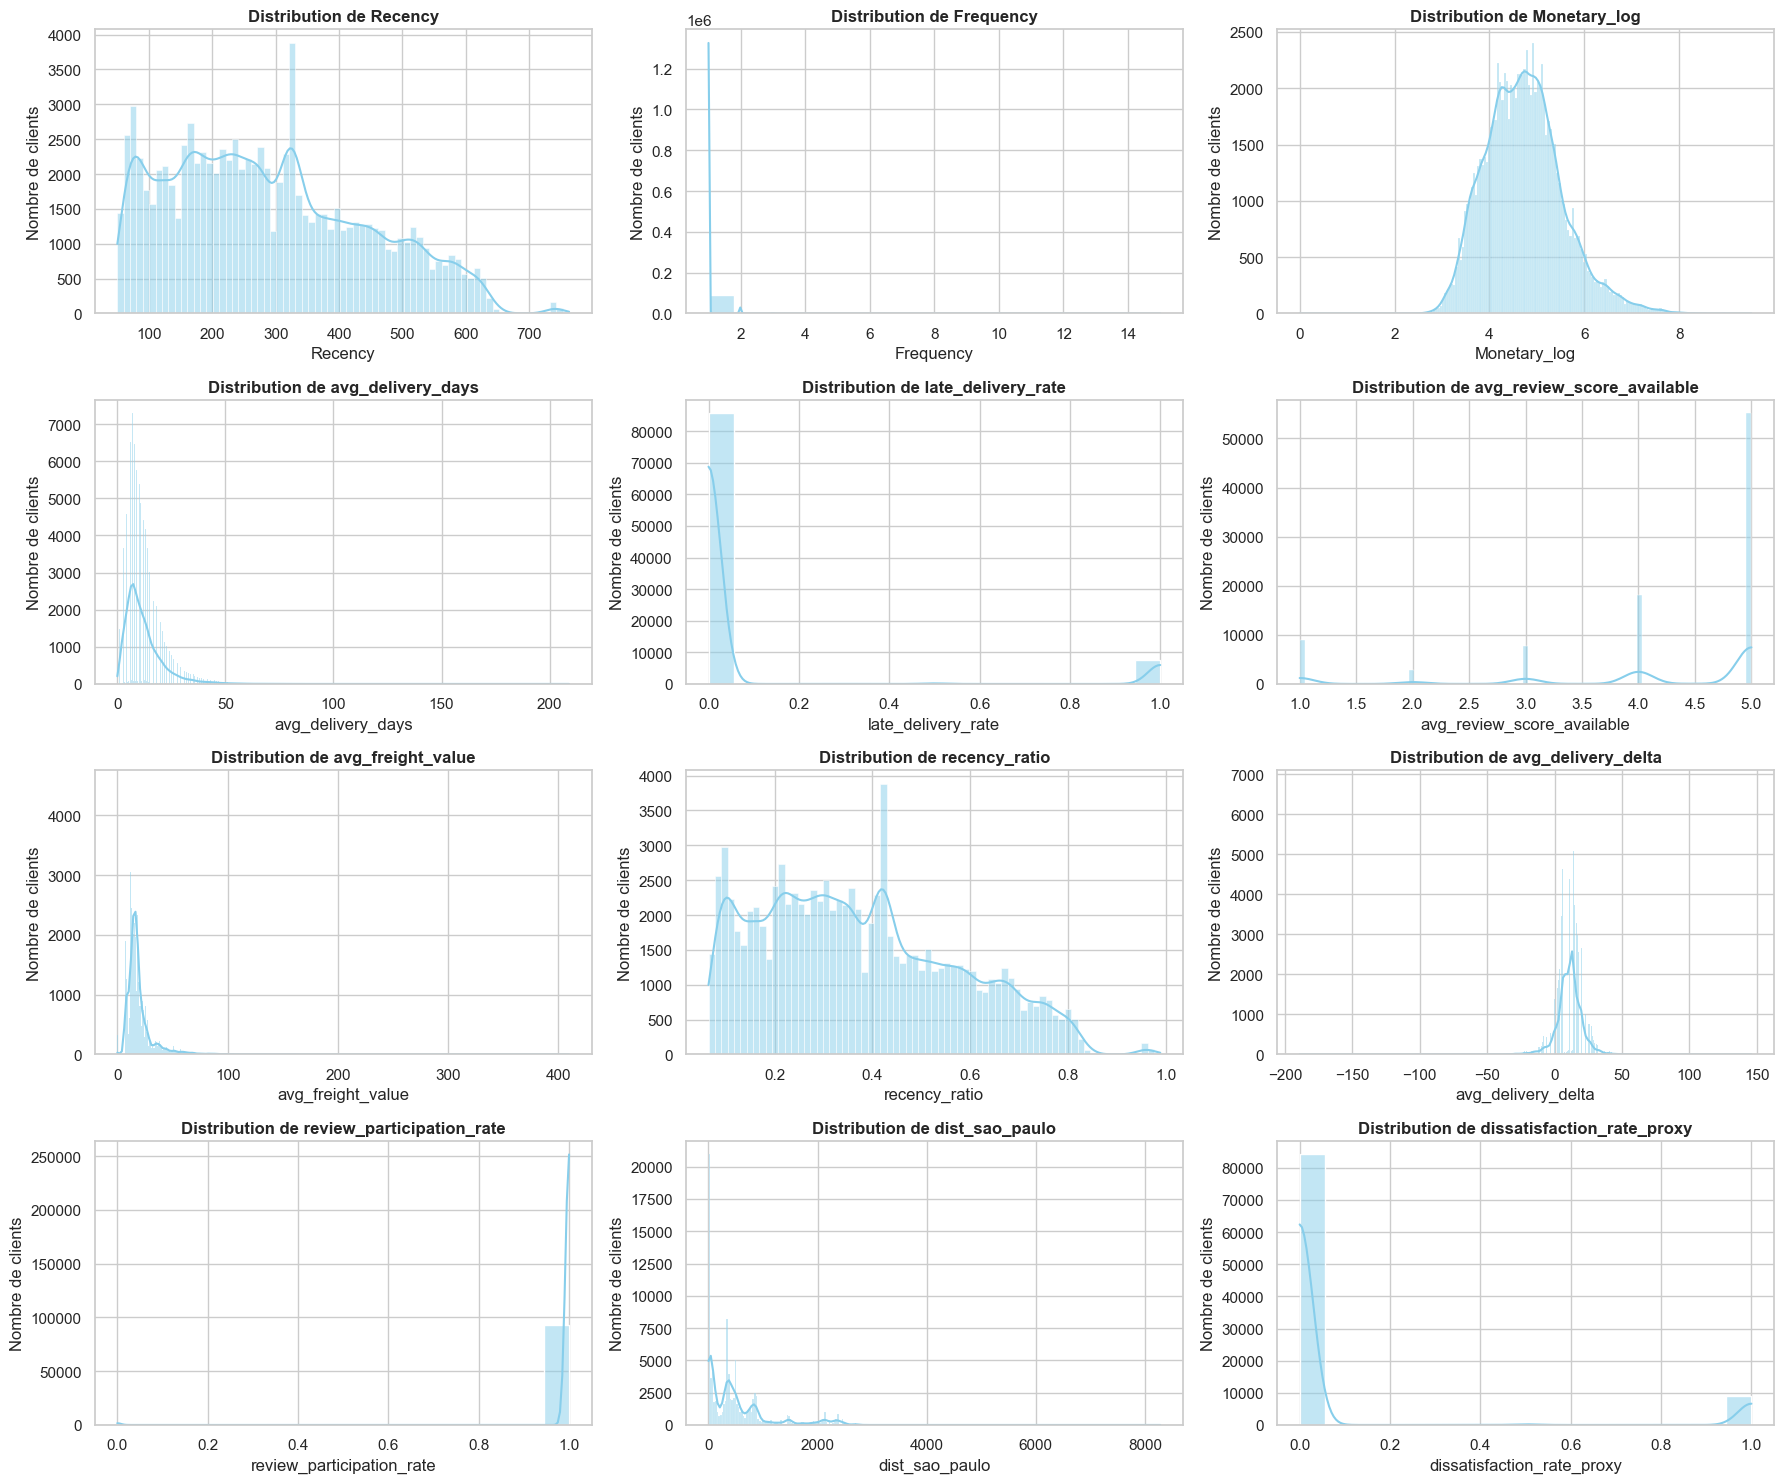


--- 5. Distributions des Variables Catégorielles Clés ---


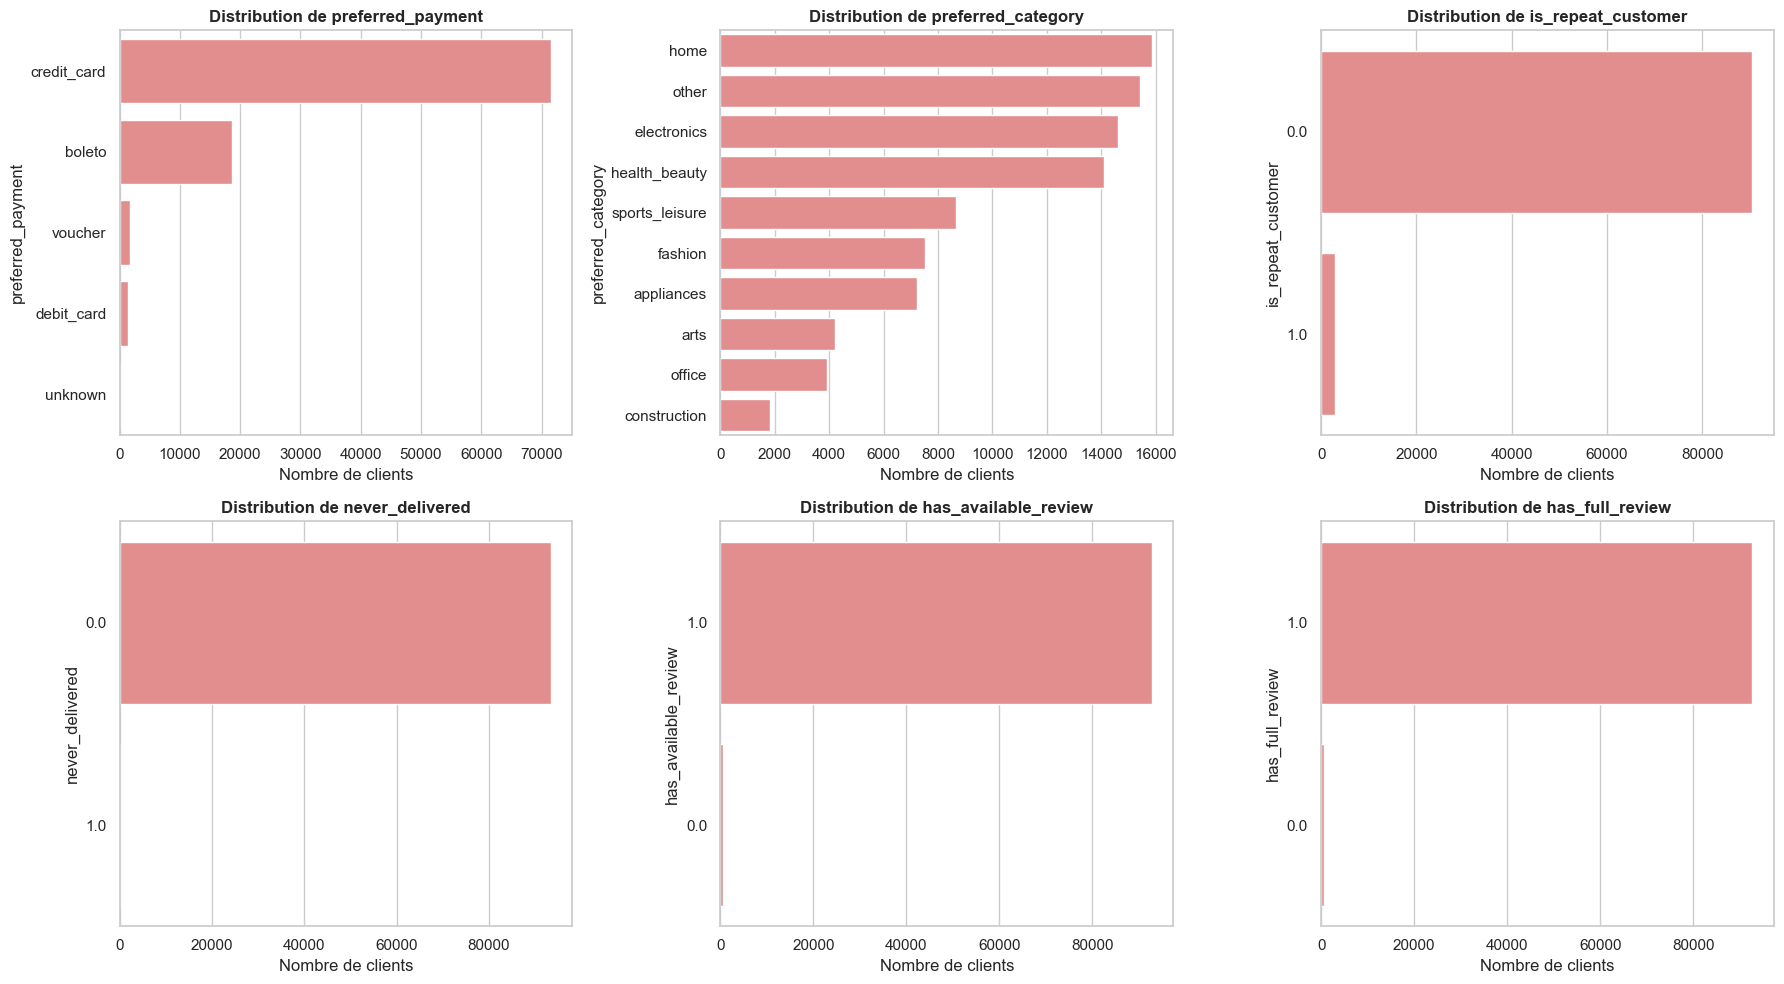


--- 6. Distributions des Dépenses par Catégorie ---


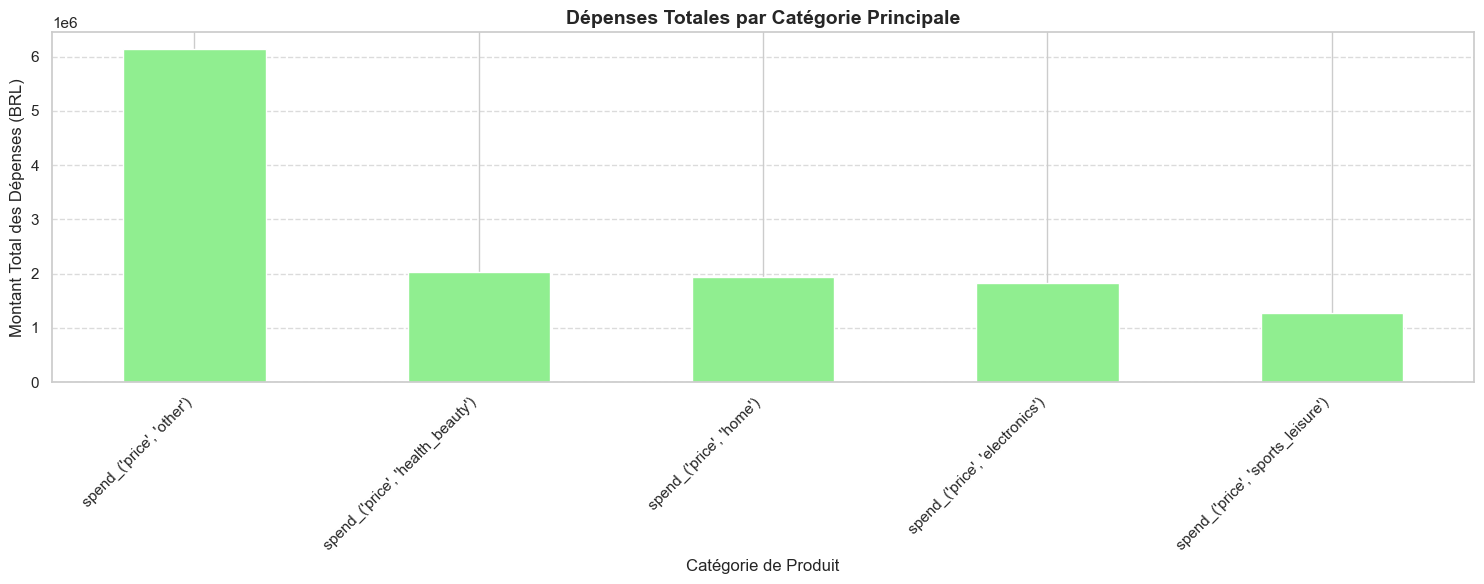


ANALYSE EXPLORATOIRE TERMINÉE


In [ ]:
# --- Analyse Exploratoire des Données Transformées --- #

print("\n" + "="*60)
print("ANALYSE EXPLORATOIRE DE df_client (DONNÉES TRANSFORMÉES)")
print("="*60)

# 1. Informations générales et aperçu
print("\n--- 1. Informations Générales ---")
df_client.info()
print("\n--- df_client.head(3) ---")
display(df_client.head(3))

# 2. Statistiques descriptives
print("\n--- 2. Statistiques Descriptives (Numériques) ---")
display(df_client.describe().T)

print("\n--- 2. Statistiques Descriptives (Catégorielles) ---")
display(df_client.describe(include=['object', 'category']).T)

# 3. Vérification finale des NA
print("\n--- 3. Vérification Finale des Valeurs Manquantes ---")
na_final = df_client.isna().sum()
na_final = na_final[na_final > 0]
if not na_final.empty:
    print("Valeurs manquantes restantes par colonne :")
    display(na_final.sort_values(ascending=False))
else:
    print("Aucune valeur manquante détectée dans df_client.")

# Préparation des colonnes pour la visualisation
# La liste NUM_COLS_LOG a été définie précédemment, mais elle est basée sur X_winsorized.
# Recréons une liste propre pour df_client incluant Monetary_log

# Assurons-nous que Monetary_log existe dans df_client pour les plots
if 'Monetary' in df_client.columns and 'Monetary_log' not in df_client.columns:
    df_client['Monetary_log'] = np.log1p(df_client['Monetary'])

# Colonnes numériques clés pour visualisation (incluant Monetary_log)
NUM_PLOTTING_COLS = [
    'Recency', 'Frequency', 'Monetary_log', 'avg_delivery_days',
    'late_delivery_rate', 'avg_review_score_available', # Use available score for plotting
    'avg_item_price',
    'avg_freight_value', 'recency_ratio', 'avg_delivery_delta',
    'review_participation_rate',
    'dist_sao_paulo',
    'dissatisfaction_rate_proxy' # Renamed for clarity
]
# Filtrer les colonnes qui existent réellement dans df_client
NUM_PLOTTING_COLS = [col for col in NUM_PLOTTING_COLS if col in df_client.columns]

# Colonnes catégorielles clés pour visualisation
CAT_PLOTTING_COLS = [
    'preferred_payment', 'preferred_category', 'is_repeat_customer',
    'never_delivered', 'has_available_review', 'has_full_review'
]
# Filtrer les colonnes qui existent réellement dans df_client
CAT_PLOTTING_COLS = [col for col in CAT_PLOTTING_COLS if col in df_client.columns]

# Colonnes de dépenses par catégorie
SPEND_COLS = [col for col in df_client.columns if col.startswith('spend_')]

# 4. Distributions des variables numériques clés (Histograms)
print("\n--- 4. Distributions des Variables Numériques Clés ---")
plt.figure(figsize=(18, 15))
for i, col in enumerate(NUM_PLOTTING_COLS):
    plt.subplot(4, 3, i + 1)
    sns.histplot(df_client[col].dropna(), kde=True, color='skyblue')
    plt.title(f'Distribution de {col}', fontsize=12, fontweight='bold')
    plt.xlabel(col)
    plt.ylabel('Nombre de clients')
plt.tight_layout()
plt.show()

# 5. Distributions des variables catégorielles (Count Plots)
print("\n--- 5. Distributions des Variables Catégorielles Clés ---")
plt.figure(figsize=(18, 10))
for i, col in enumerate(CAT_PLOTTING_COLS):
    plt.subplot(2, 3, i + 1)
    sns.countplot(y=df_client[col].dropna(), order=df_client[col].value_counts().index, color='lightcoral')
    plt.title(f'Distribution de {col}', fontsize=12, fontweight='bold')
    plt.xlabel('Nombre de clients')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

# 6. Distributions des dépenses par catégorie (Bar plots)
if SPEND_COLS:
    print("\n--- 6. Distributions des Dépenses par Catégorie ---")
    plt.figure(figsize=(15, 6))
    df_client[SPEND_COLS].sum().sort_values(ascending=False).plot(kind='bar', color='lightgreen')
    plt.title('Dépenses Totales par Catégorie Principale', fontsize=14, fontweight='bold')
    plt.xlabel('Catégorie de Produit')
    plt.ylabel('Montant Total des Dépenses (BRL)')
    plt.xticks(rotation=45, ha='right')
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
else:
    print("Aucune colonne 'spend_' trouvée pour l'analyse des dépenses par catégorie.")

print("\n" + "="*60)
print("ANALYSE EXPLORATOIRE TERMINÉE")
print("="*60)


In [ ]:
print("\n" + "="*60)
print("ANALYSE DE CORRÉLATION : Monetary vs first_purchase_value")
print("="*60)

# Corrélation pour tous les clients
corr_all = df_client['Monetary'].corr(df_client['first_purchase_value'])
print(f"\nCorrélation globale entre Monetary et first_purchase_value : {corr_all:.3f}")

# Corrélation pour les clients "one-time buyers" (Frequency == 1)
one_time_buyers = df_client[df_client['Frequency'] == 1]
if not one_time_buyers.empty:
    corr_one_time = one_time_buyers['Monetary'].corr(one_time_buyers['first_purchase_value'])
    print(f"Corrélation pour les one-time buyers : {corr_one_time:.3f}")
else:
    print("Aucun one-time buyer trouvé pour calculer la corrélation.")

print("\nInterprétation :")
if corr_one_time > 0.95: # High threshold for redundancy
    print("  La corrélation est TRÈS ÉLEVÉE (près de 1) pour les one-time buyers. Pour ces clients, Monetary et first_purchase_value sont presque identiques.")
    print("  Pour le clustering, il est recommandé de ne pas utiliser les deux features simultanément pour éviter une double pondération. Étant donné que `first_purchase_value` est une sous-catégorie de `Monetary` pour ces clients, et que `Monetary` est plus générale, on pourrait envisager de retirer `first_purchase_value` si on vise la parcimonie et éviter la redondance excessive.")
elif corr_all > 0.7 or corr_one_time > 0.7:
    print("  La corrélation est significative. Les deux features apportent des informations similaires mais peuvent avoir des nuances. Pour le clustering, les garder toutes les deux pourrait renforcer un aspect du comportement d'achat unique, mais il faut être conscient de leur lien.")
    print("  On peut envisager de conserver les deux pour l'instant, mais surveiller leur impact sur les résultats des clusters.")
else:
    print("  La corrélation n'est pas excessivement élevée. Les deux features semblent apporter des informations distinctes au-delà du cas des one-time buyers, et peuvent être conservées.")

# Note: Monetary et first_purchase_value sont inclus dans FEATURES_FULL_NUM et FEATURES_COLD_START_NUM.
# La décision de les conserver ou non sera prise après analyse de cette corrélation.



ANALYSE DE CORRÉLATION : Monetary vs first_purchase_value

Corrélation globale entre Monetary et first_purchase_value : 0.982
Corrélation pour les one-time buyers : 1.000

Interprétation :
  La corrélation est TRÈS ÉLEVÉE (près de 1) pour les one-time buyers. Pour ces clients, Monetary et first_purchase_value sont presque identiques.
  Pour le clustering, il est recommandé de ne pas utiliser les deux features simultanément pour éviter une double pondération. Étant donné que `first_purchase_value` est une sous-catégorie de `Monetary` pour ces clients, et que `Monetary` est plus générale, on pourrait envisager de retirer `first_purchase_value` si on vise la parcimonie et éviter la redondance excessive.


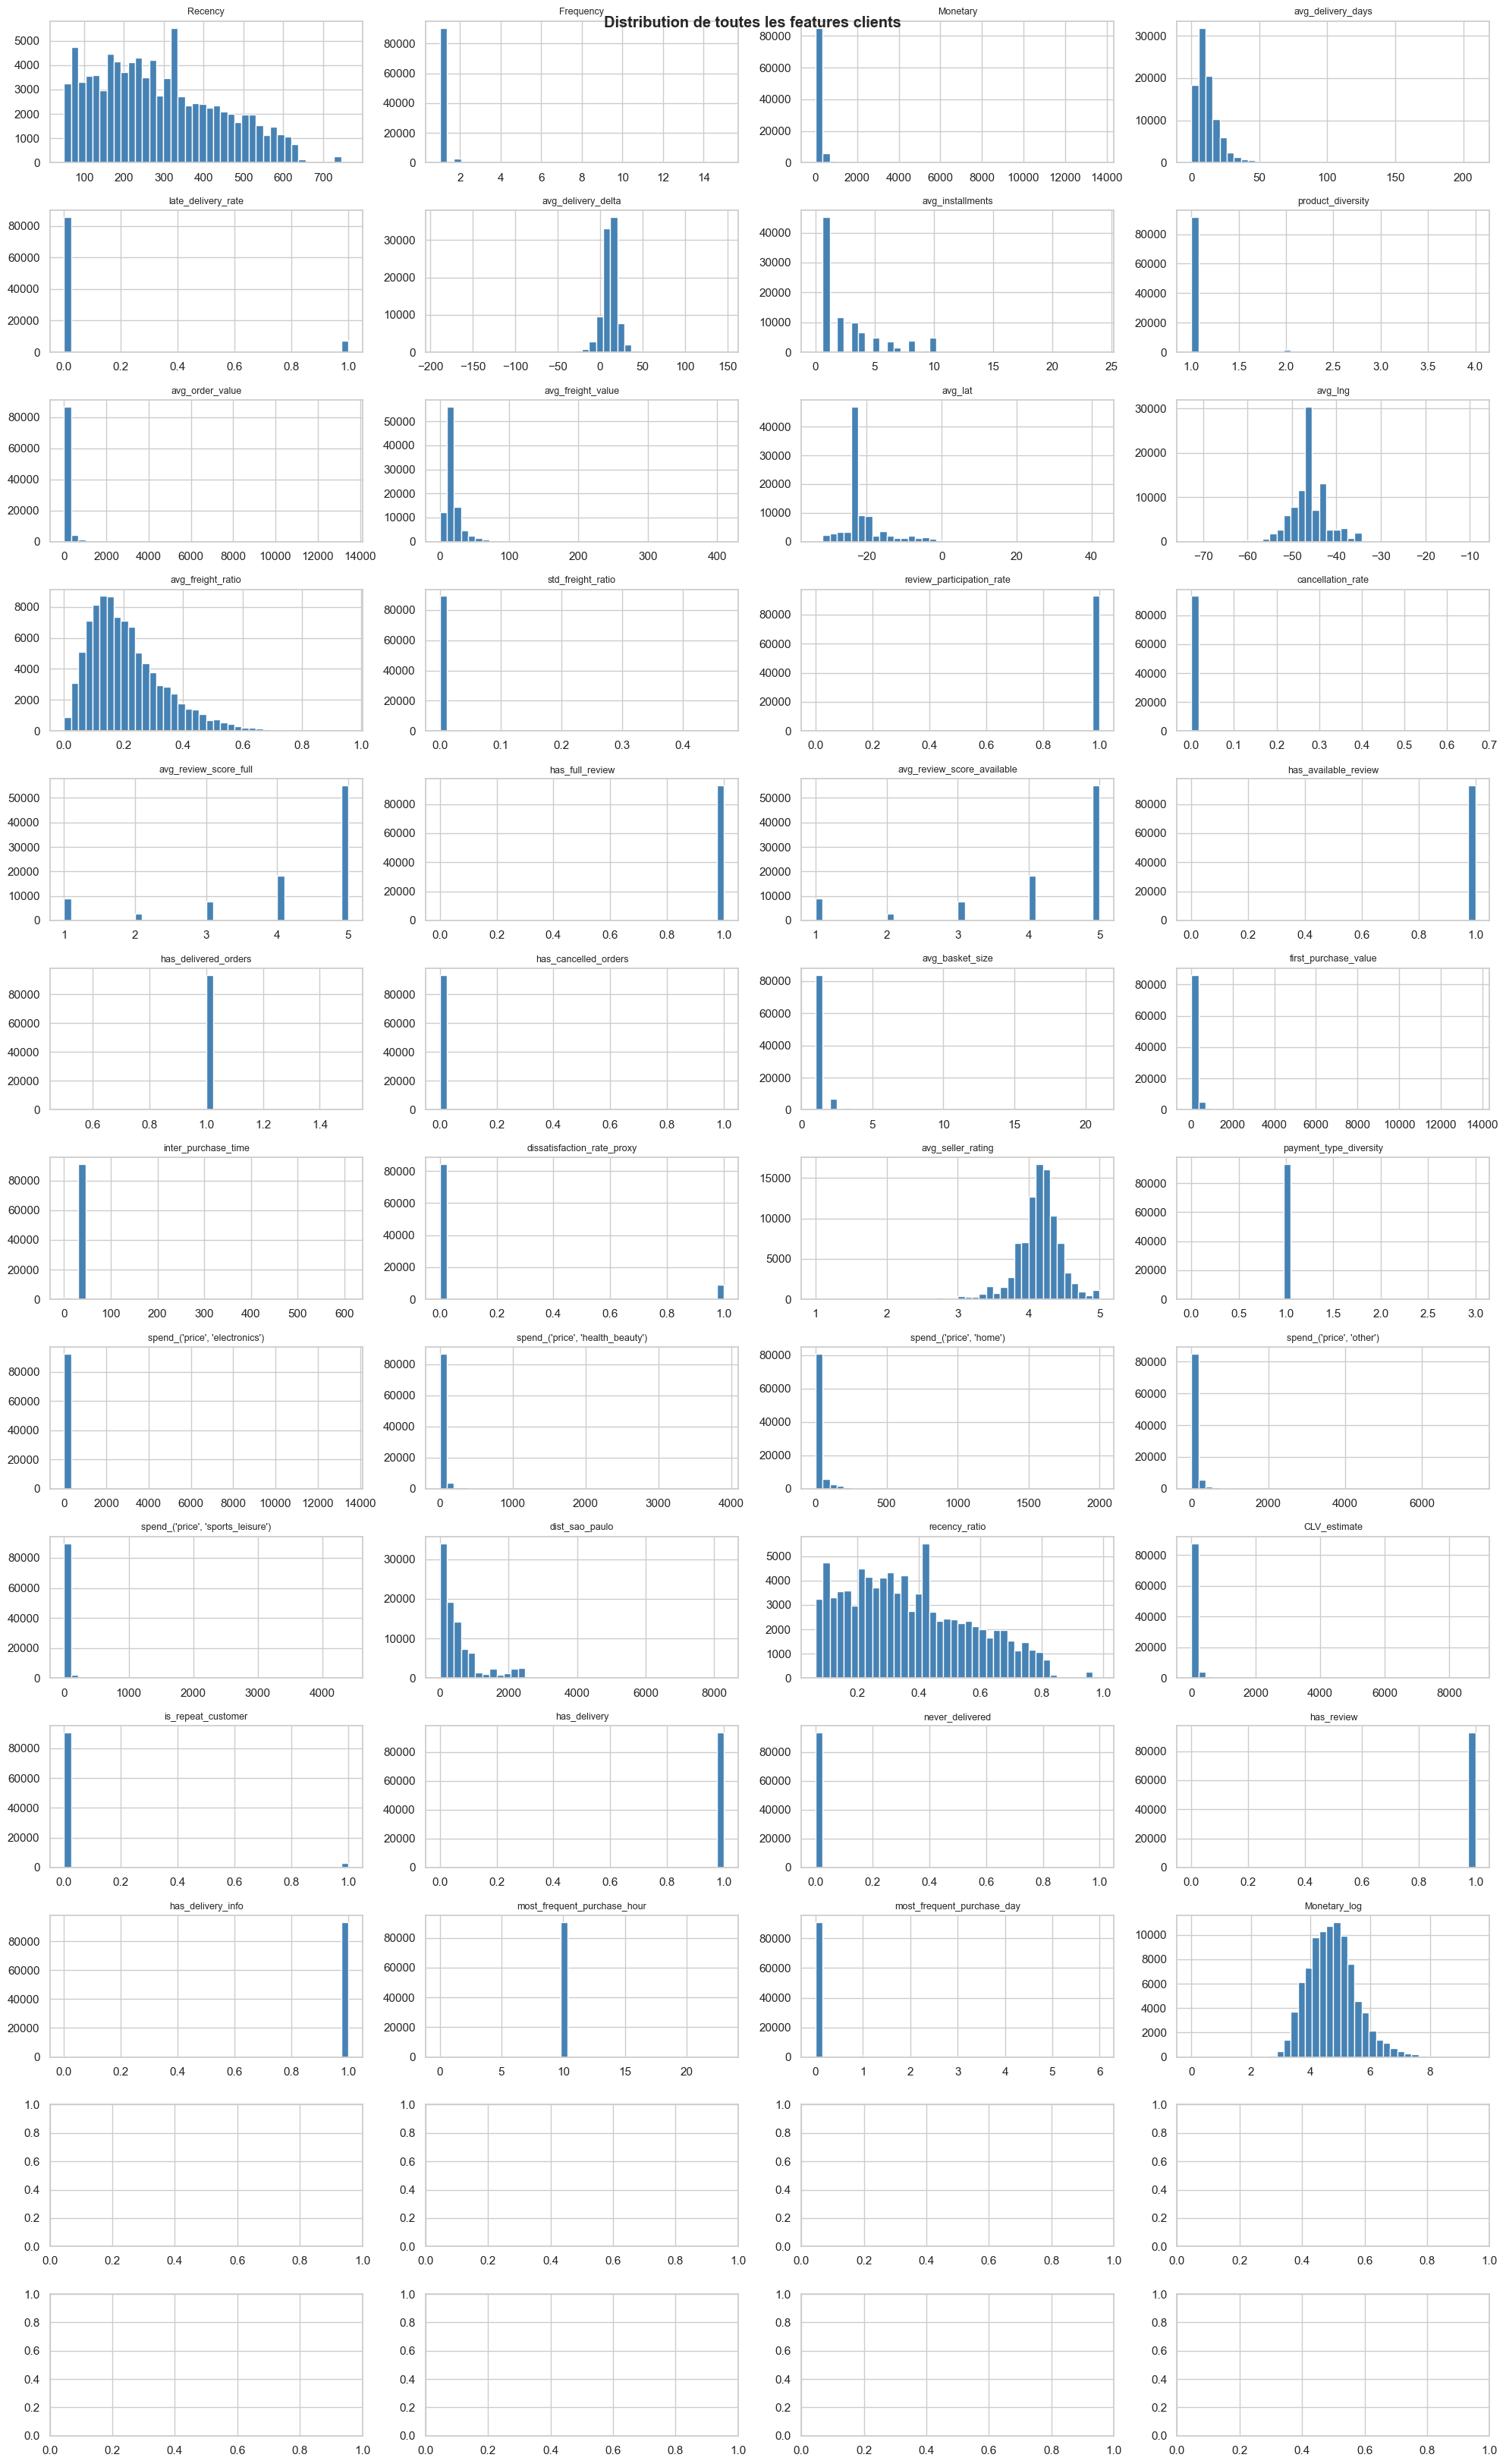

In [ ]:
# Analyse exploratoire des features créées
print("Statistiques descriptives des features principales:")
print(df_client.describe())

print("\nDistribution des variables clés:")
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.ravel()

key_features = ['Recency', 'Frequency', 'Monetary', 'avg_review_score_full', 'avg_delivery_days', 'CLV_estimate']
for i, feature in enumerate(key_features):
    if feature in df_client.columns:
        axes[i].hist(df_client[feature].dropna(), bins=50, alpha=0.7)
        axes[i].set_title(f'Distribution de {feature}')
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel('Fréquence')

plt.tight_layout()
plt.show()

print("Matrice de corrélation des features principales:")
numeric_cols = df_client.select_dtypes(include=[np.number]).columns
correlation_matrix = df_client[numeric_cols].corr()

# Afficher les corrélations les plus fortes avec les variables RFM
rfm_correlations = correlation_matrix[['Recency', 'Frequency', 'Monetary']].sort_values('Recency', ascending=False)
print("Top 20 des corrélations avec Recency:")
print(rfm_correlations.head(20))

In [ ]:
# Sauvegarde des résultats et préparation pour l'API
print("Sauvegarde des résultats du clustering:")

# Création du fichier final avec les features et les clusters
output_data = df_client.copy()

# Ajout des informations utiles pour l'API
output_data['customer_unique_id'] = df_client.index
output_data = output_data.reset_index(drop=True)

# Sauvegarde en CSV
output_filename = 'customer_segments_final.csv'
output_data.to_csv(output_filename, index=False)
print(f"Données sauvegardées dans {output_filename}")

# Sauvegarde des objets pour l'API
import joblib

# Sauvegarde du modèle, scaler et PCA
model_data = {
    'kmeans_model': kmeans_final,
    'scaler': scaler,
    'pca': pca,
    'feature_columns': feature_cols,
    'cluster_names': cluster_names,
    'optimal_k': optimal_k
}

model_filename = 'segmentation_model.pkl'
joblib.dump(model_data, model_filename)
print(f"Modèle et objets associés sauvegardés dans {model_filename}")

# Résumé final
print("\n" + "="*50)
print("RÉSUMÉ DE L'ANALYSE DE SEGMENTATION")
print("="*50)
print(f"Nombre de clients analysés: {len(df_client)}")
print(f"Nombre de features créées: {len(df_client.columns)}")
print(f"Nombre optimal de clusters: {optimal_k}")
print(f"Score silhouette final: {silhouette_avg:.3f}")
print(f"\nSegments identifiés:")
for cluster_id, name in cluster_names.items():
    count = (df_client['cluster'] == cluster_id).sum()
    percentage = count / len(df_client) * 100
    print(f"  - {name}: {count} clients ({percentage:.1f}%)")
print("\nFichiers générés:")
print(f"  - {output_filename}: Données clients avec segments")
print(f"  - {model_filename}: Modèle et objets pour l'API")

['customer_unique_id', 'Recency', 'Frequency', 'Monetary', 'avg_delivery_days', 'late_delivery_rate', 'avg_delivery_delta', 'preferred_payment', 'avg_installments', 'product_diversity', 'avg_order_value', 'avg_freight_value', 'preferred_category', 'avg_lat', 'avg_lng', 'avg_freight_ratio', 'std_freight_ratio', 'review_participation_rate', 'cancellation_rate', 'avg_review_score_full', 'has_full_review', 'avg_review_score_available', 'has_available_review', 'has_delivered_orders', 'has_cancelled_orders', 'avg_basket_size', 'first_purchase_category', 'first_purchase_value', 'inter_purchase_time', 'dissatisfaction_rate_proxy', 'avg_seller_rating', 'payment_type_diversity', "spend_('price', 'electronics')", "spend_('price', 'health_beauty')", "spend_('price', 'home')", "spend_('price', 'other')", "spend_('price', 'sports_leisure')", 'dist_sao_paulo', 'recency_ratio', 'CLV_estimate', 'is_repeat_customer', 'has_delivery', 'never_delivered', 'has_review', 'has_delivery_info', 'most_frequent_pu